# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [ ]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [ ]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [ ]:
# Q1 ANSWER:
now = Time.now()
print("ISO UTC:", now.utc.iso)
print("IIT Kanpur:", now.to_datetime(timezone=IITK_TIMEZONE).strftime("%Y-%m-%d %H:%M:%S IST"))

ISO UTC: 2026-09-06 14:41:11.543
IIT Kanpur: 2026-09-06 20:11:11 IST


Q1 Explanation: The code cannot give the same time as the answer to Time.now() since the time moves forward between the two instants that the function is called.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [ ]:
# Q2 ANSWER:
from astropy import units as u
height = 2396 * u.m
wavelength = 600 * u.nm
coord_uncertainty = 5 * u.milliarcsecond
cadence = 10 * u.min
radio_freq = 1.4 * u.GHz

height_conv = height.to (u.km)
wavelength_conv = wavelength.to (u.THz, u.spectral())
coord_uncertainty_conv = coord_uncertainty.to (u.arcsecond)
cadence_conv = cadence.to (u.h)
radio_freq_conv = radio_freq.to (u.cm, u.spectral())

print ("Height =", height, "=", height_conv)
print ("Wavelength =", wavelength, "=", wavelength_conv)
print ("Coordinate Uncertainty =", coord_uncertainty, "=", coord_uncertainty_conv)
print ("Cadence =", cadence, "=", cadence_conv)
print ("Radio Frequency =", radio_freq, "=", radio_freq_conv)

Height = 2396.0 m = 2.396 km
Wavelength = 600.0 nm = 499.6540966666666 THz
Coordinate Uncertainty = 5.0 marcsec = 0.005 arcsec
Cadence = 10.0 min = 0.16666666666666666 h
Radio Frequency = 1.4 GHz = 21.413747 cm


Q2 Explanation: The converted values are printed besides the original ones with appropriate uni conversion.

## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [ ]:
# Q3 ANSWER:
planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.iso + "Z")
print("Julian Date:", planning_start.jd)
print("Modified Julian Date:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour

print("Later UTC:", later.utc.isot + "Z")
print("Later IIT Kanpur:", format_iitk(later))

original_ist = planning_start.to_datetime(timezone=IITK_TIMEZONE)
roundtrip = Time(original_ist)

difference = abs((roundtrip - planning_start).to_value(u.s))

print("Round-trip difference:", difference, "seconds")
print("Less than 1 microsecond:", difference < 1e-6)

UTC: 2026-08-30 12:00:00.000Z
Julian Date: 2461283.0
Modified Julian Date: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30T14:15:00.000Z
Later IIT Kanpur: 2026-08-30 19:45:00 IST
Round-trip difference: 0.0 seconds
Less than 1 microsecond: True


Q3 Explanation: The Exact value may vary as per precision, but it can be verified that the difference is less than 1 us.

# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [ ]:
# Q4 ANSWER:
ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(ra=ra, dec=dec, frame="icrs")
print("RA (degrees):", frb_icrs.ra.deg)
print("Dec (degrees):", frb_icrs.dec.deg)

print("RA (sexagesimal):", frb_icrs.ra.to_string(unit=u.hourangle, sep=":", pad=True))
print("Dec (sexagesimal):", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True))

print("RA verification:", abs(frb_icrs.ra.deg - 347.2704120833) < 1e-8)
print("Dec verification:", abs(frb_icrs.dec.deg - 48.7066410556) < 1e-8)


RA (degrees): 347.27041208333327
Dec (degrees): 48.70664105555556
RA (sexagesimal): 23:09:04.8989
Dec (sexagesimal): 48:42:23.9078
RA verification: True
Dec verification: True


Q4 Explanation: The RA commonly uses hour angle becasue it is connected to Earth's rotation and Dec is expressed in degrees becasue it is the angulat distance from north or south pole of the Earth.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [ ]:
# Q5 ANSWER:
# ICRS → Galactic
frb_galactic = frb_icrs.galactic
print("Galactic l (longitude):", frb_galactic.l.deg)
print("Galactic b (latitude):", frb_galactic.b.deg)

# Galactic → ICRS
frb_icrs_back = frb_galactic.icrs
separation = frb_icrs.separation(frb_icrs_back)
print("Round-trip separation:", separation.to(u.microarcsecond))

Galactic l (longitude): 106.06496077332801
Galactic b (latitude): -10.784176285402493
Round-trip separation: 0.000310733 uarcsec


Q5 Explanation: The residual error exists because of rounding off and floating point precision.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [ ]:
# Q6 ANSWER:
# ICRS -> Barycentric True Ecliptic (J2000)
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox=Time("J2000"))
)

print("Ecliptic longitude (lambda):", frb_ecliptic.lon.deg, "deg")
print("Ecliptic latitude (beta):", frb_ecliptic.lat.deg, "deg")

# Check valid ranges
print("Lambda in valid range:", 0 <= frb_ecliptic.lon.deg < 360)
print("Beta in valid range:", -90 <= frb_ecliptic.lat.deg <= 90)

# Ecliptic -> ICRS
frb_icrs_back = frb_ecliptic.transform_to("icrs")

# Round-trip separation
round_trip = frb_icrs.separation(frb_icrs_back)

print("Round-trip separation:", round_trip.to(u.microarcsecond))

Ecliptic longitude (lambda): 14.411187650340095 deg
Ecliptic latitude (beta): 48.34695843744783 deg
Lambda in valid range: True
Beta in valid range: True
Round-trip separation: 0 uarcsec


Q6 Explanation: Ecliptic latitude β measures the angular distance of an object north or south of this plane, while ecliptic longitude λ specifies its angular position along the ecliptic.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [ ]:
# Q7 ANSWER:
# Construct the earlier position
earlier_ra = Angle(EARLIER_POSITION_RA)
earlier_dec = Angle(EARLIER_POSITION_DEC)

earlier_position = SkyCoord(ra=earlier_ra, dec=earlier_dec, frame="icrs")
print(earlier_position)

alpha1 = frb_icrs.ra.rad
delta1 = frb_icrs.dec.rad

alpha2 = earlier_position.ra.rad
delta2 = earlier_position.dec.rad

print("Alpha1 =", alpha1, "\nDelta1 =", delta1, "\nAlpha2 = ", alpha2, "\nDelta2 =", delta2)

# Spherical cosine formula
cos_theta = (np.sin(delta1) * np.sin(delta2) + np.cos(delta1) * np.cos(delta2) * np.cos(alpha2 - alpha1))

# Protect against floating-point errors
cos_theta = np.clip(cos_theta, -1.0, 1.0)
theta = np.arccos(cos_theta)\

# Convert to arcseconds
theta_arcsec = np.degrees(theta) * 3600
theta_mas = theta_arcsec * 1000

print("Manual separation:", theta_arcsec * (u.arcsecond))
print("Manual separation:", theta_mas * (u.milliarcsecond))

# Astropy calculation
astropy_separation = frb_icrs.separation(earlier_position)

print("Astropy separation:", astropy_separation.to(u.arcsec))

# Required agreement
difference = abs(
    theta_arcsec - astropy_separation.to_value(u.arcsec)
)

print("Difference:", difference, "arcsec")
print("Agreement within 1e-6 arcsec:", difference < 1e-6)

<SkyCoord (ICRS): (ra, dec) in deg
    (347.27041667, 48.70705556)>
Alpha1 = 6.061012085611666 
Delta1 = 0.8500912540064909 
Alpha2 =  6.061012165605924 
Delta2 = 0.8500984883962404
Manual separation: 1.4922374490540065 arcsec
Manual separation: 1492.2374490540064 marcsec
Astropy separation: 1.49224 arcsec
Difference: 2.277149442564408e-06 arcsec
Agreement within 1e-6 arcsec: False


Q7 Explanation: Floating point precision error causes the agreement boolean variable to show the output as False.

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [ ]:
# Q8 ANSWER:
gtc_location = EarthLocation.from_geodetic (lon=GTC_LONGITUDE_DEG * u.deg, lat=GTC_LATITUDE_DEG * u.deg, height=GTC_HEIGHT_M * u.m)

print("GTC longitude:", gtc_location.lon.to(u.deg))
print("GTC latitude:", gtc_location.lat.to(u.deg))
print("GTC height:", gtc_location.height.to(u.m))

GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999997463 m


Q8 Explanation: Negative longitude means the location is at the West of the meridian.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [ ]:
# Q9 ANSWER:
q9_time = Time("2026-08-31T00:00:00", scale="utc")

# Apparent Local Sidereal Time at GTC
lst = q9_time.sidereal_time("apparent", longitude=gtc_location.lon)

# Hour angle H = LST - RA
hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", format_utc(q9_time))
print("IIT Kanpur:", format_iitk(q9_time))
print("LST:", lst.to_string(unit=u.hourangle, sep=":", pad=True))
print("Hour angle:", hour_angle.to_string(unit=u.hourangle, sep=":", pad=True))

# Determine position relative to meridian
if hour_angle < 0 * u.hourangle:
    print("The target is east of the meridian.")
elif hour_angle > 0 * u.hourangle:
    print("The target is west of the meridian.")
else:
    print("The target is transiting.")

UTC: 2026-08-31 00:00:00 UTC
IIT Kanpur: 2026-08-31 05:30:00 IST
LST: 21:25:12.20821623
Hour angle: -01:43:52.69068377
The target is east of the meridian.


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [ ]:
# Q10 ANSWER:
# Calculate apparent LST for all 145 samples
lst_all = times.sidereal_time("apparent", longitude=gtc_location.lon)

# Calculate wrapped hour angle using the RA from Q4
hour_angle_all = (lst_all - frb_icrs.ra).wrap_at(12 * u.hourangle)

# Find the sample closest to the meridian: H = 0
idx = np.argmin(np.abs(hour_angle_all.to_value(u.hourangle)))

# Get the corresponding values
transit_time = times[idx]
transit_lst = lst_all[idx]
transit_H = hour_angle_all[idx]

print("Sample index:", idx)
print("UTC:", format_utc(transit_time))
print("IIT Kanpur:", format_iitk(transit_time))
print("LST:", transit_lst.to_string(unit=u.hourangle, sep=":", pad=True))
print("Hour angle:", transit_H.to_string(unit=u.hourangle, sep=":", pad=True))

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur: 2026-08-31 07:10:00 IST
LST: 23:05:28.63507714
Hour angle: -00:03:36.26382286


Q10 Explanation: The samples are taken in a 10 minute interval and hence it may be possible that the transit has already happened. therefore, it is not necessarily the exact moment.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [ ]:
# Q11 ANSWER:
# GTC latitude and target declination
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

#Theoretical angles
# Upper-transit
predicted_altitude = 90 * u.deg - np.abs(phi - delta)
# Zenith distance
predicted_zenith_distance = 90 * u.deg - predicted_altitude

print("Predicted transit altitude:", predicted_altitude)
print("Predicted zenith distance:", predicted_zenith_distance)

# GTC AltAz frame for all 145 times
altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)

# Transform target to AltAz
frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)

# Largest sampled altitude
max_index = np.argmax(frb_gtc_altaz.alt)
max_altitude = frb_gtc_altaz.alt[max_index]

# Corresponding sampled zenith distance
sampled_zenith_distance = 90 * u.deg - max_altitude

print("\nLargest sampled altitude:", max_altitude)
print("Sample index:", max_index)
print("Sample UTC:", format_utc(times[max_index]))
print("Sample IIT Kanpur:", format_iitk(times[max_index]))
print("Sampled zenith distance:", sampled_zenith_distance)

# Compare
altitude_difference = max_altitude - predicted_altitude
zenith_difference = sampled_zenith_distance - predicted_zenith_distance

print("\nAltitude difference:", altitude_difference)
print("Zenith-distance difference:", zenith_difference)

alt_conv = altitude_difference.to (u.arcsecond)
zen_conv = zenith_difference.to (u.arcsecond)

print("\nAltitude conv =", alt_conv)
print("Zenith-distance conv =", zen_conv)

Predicted transit altitude: 70d03m04.8922s
Predicted zenith distance: 19d56m55.1078s

Largest sampled altitude: 69d53m02.08616823s
Sample index: 82
Sample UTC: 2026-08-31 01:40:00 UTC
Sample IIT Kanpur: 2026-08-31 07:10:00 IST
Sampled zenith distance: 20d06m57.91383177s

Altitude difference: -0d10m02.80603177s
Zenith-distance difference: 0d10m02.80603177s

Altitude conv = -602.806 arcsec
Zenith-distance conv = 602.806 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [ ]:
# Q12 ANSWER:
# Use the nearest transit index found in Q11/Q10
transit_idx = max_index

indices = [
    transit_idx - 12,   # 2 hours before
    transit_idx,        # nearest transit
    transit_idx + 12    # 2 hours after
    ]

labels = [
    "2 hours before transit",
    "Nearest transit",
    "2 hours after transit"
    ]

for label, idx in zip(labels, indices):

    H = hour_angle_all[idx]

    # Convert H to radians
    H_rad = H.to_value(u.rad)
    phi_rad = phi.to_value(u.rad)
    delta_rad = delta.to_value(u.rad)

    # Altitude equation
    sin_h = (np.sin(phi_rad) * np.sin(delta_rad) + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(H_rad))

    # Protect against floating-point errors
    sin_h = np.clip(sin_h, -1.0, 1.0)

    calculated_altitude = np.arcsin(sin_h) * u.rad
    calculated_altitude = calculated_altitude.to(u.deg)
    astropy_altitude = frb_gtc_altaz.alt[idx]
    difference = calculated_altitude - astropy_altitude

    print("\n", label)
    print("Sample index:", idx)
    print("UTC:", format_utc(times[idx]))
    print("IST:", format_iitk(times[idx]))
    print("Hour angle:", H.to_string(unit=u.hourangle, sep=":", pad=True))
    print("Calculated altitude:", calculated_altitude)
    print("Astropy altitude:", astropy_altitude)
    print("Difference:", difference)


 2 hours before transit
Sample index: 70
UTC: 2026-08-30 23:40:00 UTC
IST: 2026-08-31 05:10:00 IST
Hour angle: -02:03:55.97605409
Calculated altitude: 59.031948665002126 deg
Astropy altitude: 58d46m53.67263948s
Difference: 0d15m01.34255453s

 Nearest transit
Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Hour angle: -00:03:36.26382286
Calculated altitude: 70.039347468167 deg
Astropy altitude: 69d53m02.08616823s
Difference: 0d09m19.56471717s

 2 hours after transit
Sample index: 94
UTC: 2026-08-31 03:40:00 UTC
IST: 2026-08-31 09:10:00 IST
Hour angle: 01:56:43.44842115
Calculated altitude: 60.063043754805115 deg
Astropy altitude: 60d09m45.39530037s
Difference: -0d05m58.43778307s


Q12 Explanation: The source altitude increases as it approaches the meridian, reaches its maximum near transit, and then decreases as it moves away from the meridian.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [ ]:
# Q13 ANSWER:
h_min = MIN_TARGET_ALTITUDE_DEG * u.deg

phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)
h_min_rad = h_min.to_value(u.rad)

cos_H0 = (np.sin(h_min_rad) - np.sin(phi_rad) * np.sin(delta_rad)) / (np.cos(phi_rad) * np.cos(delta_rad))

cos_H0 = np.clip(cos_H0, -1.0, 1.0)

H0_rad = np.arccos(cos_H0)

H0_deg = np.degrees(H0_rad)
H0_hours = H0_deg / 15.0

total_hours = 2 * H0_hours

# Number of sampled points above 20 degrees
above_20 = frb_gtc_altaz.alt >= h_min
number_above_20 = np.count_nonzero(above_20)

print("H0:", H0_deg, "deg")
print("H0:", H0_hours, "sidereal hours")
print("Total time above 20 deg:", total_hours, "hours")
print("Number of grid samples above 20 deg:", number_above_20)

# Approximate sampled duration
sampled_duration = (number_above_20 - 1) * STEP_MINUTES / 60

print("Sampled interval duration:", sampled_duration, "hours")

H0: 91.92747700350239 deg
H0: 6.128498466900159 sidereal hours
Total time above 20 deg: 12.256996933800318 hours
Number of grid samples above 20 deg: 74
Sampled interval duration: 12.166666666666666 hours


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [ ]:
# Q14 ANSWER:
target_airmass = np.asarray(frb_gtc_altaz.secz.value, dtype=float)

# Invalid if below/at horizon, non-finite, or X < 1
invalid = ((frb_gtc_altaz.alt <= 0 * u.deg) | (~np.isfinite(target_airmass)) | (target_airmass < 1))

target_airmass[invalid] = np.nan

# Finite values
finite = np.isfinite(target_airmass)

print("Finite airmass range:")
print("Minimum:", np.nanmin(target_airmass))
print("Maximum:", np.nanmax(target_airmass))

# Best airmass
best_idx = np.nanargmin(target_airmass)
best_airmass = target_airmass[best_idx]

print("\nBest airmass:", best_airmass)
print("Best-airmass UTC:", format_utc(times[best_idx]))
print("Best-airmass IIT Kanpur:", format_iitk(times[best_idx]))

# Samples with 1 <= X <= 2.5
good_airmass = (finite & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS))

print("\nNumber of samples with 1 <= X <= 2.5:", np.count_nonzero(good_airmass))

Finite airmass range:
Minimum: 1.0649653072737555
Maximum: 55.33845064849153

Best airmass: 1.0649653072737555
Best-airmass UTC: 2026-08-31 01:40:00 UTC
Best-airmass IIT Kanpur: 2026-08-31 07:10:00 IST

Number of samples with 1 <= X <= 2.5: 68


Q14 Explanation: Below-horizon airmass values must not be used because airmass represents the atmospheric path length for an object being observed above the horizon. Also, 1/sec(z) becomes inf when z = 90 degrees.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [ ]:
# Q15 ANSWER:
with solar_system_ephemeris.set("builtin"):

# Sun and Moon positions
  sun = get_sun(times)
  moon = get_body("moon", times)

# AltAz frame
altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)

# Sun and Moon altitude
sun_altaz = sun.transform_to(altaz_frame)
moon_altaz = moon.transform_to(altaz_frame)

sun_altitude = sun_altaz.alt
moon_altitude = moon_altaz.alt

# Moon airmass
moon_airmass = np.asarray(moon_altaz.secz.value, dtype=float)

# Keep Moon airmass only when above horizon and 1 <= X <= 3
valid_moon_airmass = (
    (moon_altitude > 0 * u.deg)
    & np.isfinite(moon_airmass)
    & (moon_airmass >= 1)
    & (moon_airmass <= 3)
)

moon_airmass[~valid_moon_airmass] = np.nan

# Moon-target separation
moon_target_separation = moon.separation(frb_icrs)

# Sun-Moon geocentric elongation
elongation = sun.separation(moon)

# Illuminated fraction
illuminated_fraction = (
    1 - np.cos(elongation.to_value(u.rad))
) / 2

# Classification
moon_labels = np.full(len(times), "Unknown", dtype=object)

finite_inputs = (
    np.isfinite(moon_altitude.to_value(u.deg))
    & np.isfinite(moon_target_separation.to_value(u.deg))
    & np.isfinite(illuminated_fraction)
)

# Bright rule
bright = (
    finite_inputs
    & (
        (
            (illuminated_fraction >= 0.70)
            & (moon_altitude.to_value(u.deg) > 10)
        )
        |
        (moon_target_separation.to_value(u.deg) <= 45)
    )
)

moon_labels[finite_inputs] = "Gray"
moon_labels[bright] = "Bright"

# Dark rule
dark = (
    finite_inputs
    & (
        (moon_altitude.to_value(u.deg) < 0)
        |
        (
            (moon_target_separation.to_value(u.deg) >= 90)
            & (illuminated_fraction <= 0.25)
        )
    )
)

# Dark is applied second, so it overrides Bright
moon_labels[dark] = "Dark"

# Find nearest transit sample
transit_idx = max_index

print("Sun altitude at transit:",
      sun_altitude[transit_idx])

print("Moon altitude at transit:",
      moon_altitude[transit_idx])

print("Moon airmass at transit:",
      moon_airmass[transit_idx])

print("Moon-target separation at transit:",
      moon_target_separation[transit_idx])

print("Illuminated fraction at transit:",
      illuminated_fraction[transit_idx])

print("Moon label at transit:",
      moon_labels[transit_idx])

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

Sun altitude at transit: -51d57m21.31876165s
Moon altitude at transit: 59d05m45.35620029s
Moon airmass at transit: 1.1654625278023825
Moon-target separation at transit: 44d46m35.95410664s
Illuminated fraction at transit: 0.9081719061723459
Moon label at transit: Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [ ]:
# Q16 ANSWER:
def visibility(altitude, airmass, sun_altitude, moon_separation):

    altitude = u.Quantity(altitude, u.deg)
    sun_altitude = u.Quantity(sun_altitude, u.deg)
    moon_separation = u.Quantity(moon_separation, u.deg)
    airmass = np.asarray(airmass, dtype=float)

    # Check dimensions
    if not all(x.ndim == 1 for x in
               [altitude, airmass, sun_altitude, moon_separation]):
        raise ValueError("All inputs must be one-dimensional.")

    # Check equal lengths
    if not (
        len(altitude) == len(airmass) ==
        len(sun_altitude) == len(moon_separation)
    ):
        raise ValueError("All inputs must have equal length.")

    # Individual conditions
    altitude_ok = (altitude >= 20 * u.deg)

    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= 2.5)
    )

    sun_ok = (sun_altitude <= -18 * u.deg)

    moon_ok = (moon_separation >= 30 * u.deg)

    # Combined condition
    visible = (
        altitude_ok
        & airmass_ok
        & sun_ok
        & moon_ok
    )

    print("Altitude condition:", np.count_nonzero(altitude_ok))
    print("Airmass condition:", np.count_nonzero(airmass_ok))
    print("Sun condition:", np.count_nonzero(sun_ok))
    print("Moon separation condition:", np.count_nonzero(moon_ok))
    print("Combined visible samples:", np.count_nonzero(visible))
    print("Overall visibility:", np.any(visible))

    return visible


preferred_visibility = visibility(
    frb_gtc_altaz.alt,
    target_airmass,
    sun_altitude,
    moon_target_separation
)

Altitude condition: 74
Airmass condition: 68
Sun condition: 51
Moon separation condition: 145
Combined visible samples: 51
Overall visibility: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [ ]:
# Q17 ANSWER:
test_times = [
    ("Nearest sampled transit", times[max_index]),
    ("2026-08-31T06:00:00Z", Time("2026-08-31T06:00:00", scale="utc"))
]

for label, t in test_times:

    # Target AltAz
    target = frb_icrs.transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    # Sun
    sun_t = get_sun(t).transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    # Moon
    moon_t = get_body("moon", t).transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    # Moon-target separation
    moon_icrs_t = get_body("moon", t)
    moon_sep = moon_icrs_t.separation(frb_icrs)

    # Airmass
    X = target.secz.value

    # Individual conditions
    altitude_ok = target.alt >= 20 * u.deg

    airmass_ok = (
        np.isfinite(X)
        and X >= 1
        and X <= 2.5
    )

    sun_ok = sun_t.alt <= -18 * u.deg

    moon_ok = moon_sep >= 30 * u.deg

    final = (
        altitude_ok
        and airmass_ok
        and sun_ok
        and moon_ok
    )

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)

    print("UTC:", format_utc(t))
    print("IST:", format_iitk(t))
    print("Altitude:", target.alt)
    print("Airmass:", X)
    print("Sun altitude:", sun_t.alt)
    print("Moon separation:", moon_sep)

    print("\nConditions:")
    print("Altitude >= 20 deg:", altitude_ok)
    print("1 <= Airmass <= 2.5:", airmass_ok)
    print("Sun altitude <= -18 deg:", sun_ok)
    print("Moon separation >= 30 deg:", moon_ok)

    print("\nFinal visibility:", final)


Nearest sampled transit
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69d53m02.08616823s
Airmass: 1.0649653072737555
Sun altitude: -51d57m21.31876165s
Moon separation: 44d46m35.95410664s

Conditions:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: True
Moon separation >= 30 deg: True

Final visibility: True

2026-08-31T06:00:00Z
UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37d59m11.35178503s
Airmass: 1.6247597704376868
Sun altitude: -11d16m55.3323849s
Moon separation: 44d35m08.91729153s

Conditions:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: False
Moon separation >= 30 deg: True

Final visibility: False


# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

In [ ]:
# Q18 ANSWER:
def stitch_windows(times, visibility_state):

    times = np.asarray(times)
    visibility_state = np.asarray(visibility_state, dtype=bool)

    if len(times) != len(visibility_state):
        raise ValueError("times and visibility_state must have equal length")

    windows = []
    start = None

    for i, visible in enumerate(visibility_state):

        if visible and start is None:
            start = i

        if start is not None:
            if (not visible) or i == len(visibility_state) - 1:

                end = i if visible and i == len(visibility_state) - 1 else i - 1

                windows.append((start, end))
                start = None

    return windows

In [ ]:
windows = stitch_windows(times, preferred_visibility)

print("Observable windows:")

for start, end in windows:

    print("\nSample indices:", start, "to", end)

    print("Start UTC:", format_utc(times[start]))
    print("Start IST:", format_iitk(times[start]))

    print("End UTC:", format_utc(times[end]))
    print("End IST:", format_iitk(times[end]))

    # Inclusive sample-centre duration
    duration = (
        times[end] - times[start]
    ).to_value(u.hour)

    print("Sample-centre duration:", duration, "hours")

    # Best target airmass in interval
    interval_airmass = target_airmass[start:end + 1]

    best_local = np.nanargmin(interval_airmass)
    best_index = start + best_local

    print("Best target airmass:", target_airmass[best_index])
    print("Best-airmass UTC:", format_utc(times[best_index]))
    print("Best-airmass IST:", format_iitk(times[best_index]))

    # Midpoint Moon label
    midpoint = (start + end) // 2

    print("Midpoint Moon label:", moon_labels[midpoint])

Observable windows:

Sample indices: 54 to 104
Start UTC: 2026-08-30 21:00:00 UTC
Start IST: 2026-08-31 02:30:00 IST
End UTC: 2026-08-31 05:20:00 UTC
End IST: 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333333333333332 hours
Best target airmass: 1.0649653072737555
Best-airmass UTC: 2026-08-31 01:40:00 UTC
Best-airmass IST: 2026-08-31 07:10:00 IST
Midpoint Moon label: Bright


In [ ]:
import os

os.makedirs("assignment_outputs", exist_ok=True)

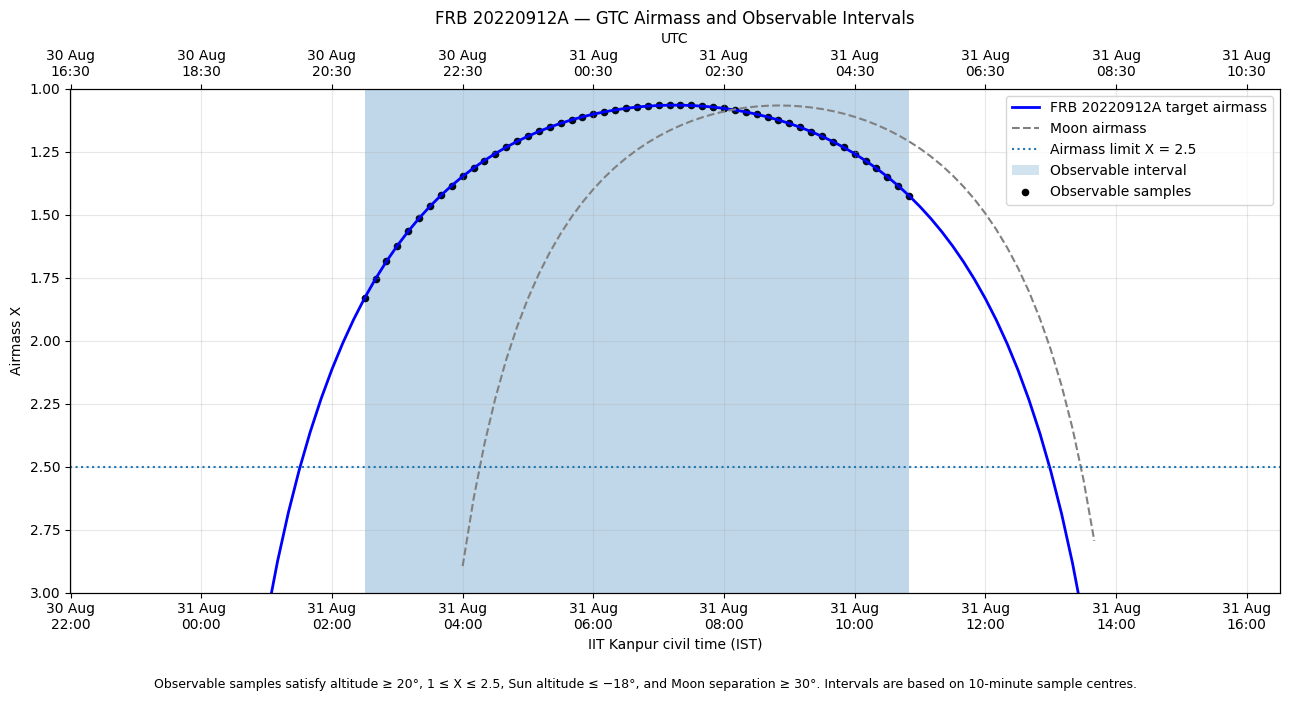

Saved: assignment_outputs/frb_20220912a_gtc_airmass.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory

# Convert Astropy times to Python datetimes
time_dt = times.to_datetime(timezone=IITK_TIMEZONE)

target_X = target_airmass

# Moon airmass from Q15
moon_X = moon_airmass

fig, ax = plt.subplots(figsize=(13, 7))

# Target airmass
ax.plot(
    time_dt,
    target_X,
    linestyle="-",
    linewidth=2,
    color="blue",
    label="FRB 20220912A target airmass"
)

# Moon airmass
ax.plot(
    time_dt,
    moon_X,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label="Moon airmass"
)

# Airmass limit
ax.axhline(
    2.5,
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit X = 2.5"
)

# Observable intervals
for start, end in windows:

    ax.axvspan(
        time_dt[start],
        time_dt[end],
        alpha=0.2,
        label="Observable interval"
    )

# Observable sample markers
visible_indices = np.where(preferred_visibility)[0]

ax.scatter(
    time_dt[visible_indices],
    target_X[visible_indices],
    marker="o",
    color="black",
    s=20,
    label="Observable samples"
)

# Twilight/night bands
# Astronomical night = Sun altitude <= -18 degrees
night = sun_altitude <= -18 * u.deg

# Shade contiguous night regions
night_start = None

for i, is_night in enumerate(night):

    if is_night and night_start is None:
        night_start = i

    if night_start is not None:
        if (not is_night) or i == len(night) - 1:

            night_end = (
                i if is_night and i == len(night) - 1
                else i - 1
            )

            ax.axvspan(
                time_dt[night_start],
                time_dt[night_end],
                alpha=0.10
            )

            night_start = None

# Inverted 3-to-1 airmass axis
ax.set_ylim(3, 1)

ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur civil time (IST)")

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b\n%H:%M", tz=IITK_TIMEZONE)
)

ax.grid(True, alpha=0.3)

# UTC axis above
ax_utc = ax.twiny()

ax_utc.set_xlim(ax.get_xlim())

utc_dt = times.to_datetime(timezone=timezone.utc)

# Match ticks to main axis
ticks = ax.get_xticks()
ax_utc.set_xticks(ticks)

ax_utc.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b\n%H:%M", tz=timezone.utc)
)

ax_utc.set_xlabel("UTC")

# Avoid duplicate legend entries
handles, labels = ax.get_legend_handles_labels()

unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    loc="best"
)

ax.set_title(
    "FRB 20220912A — GTC Airmass and Observable Intervals"
)

fig.text(
    0.5,
    0.01,
    "Observable samples satisfy altitude ≥ 20°, "
    "1 ≤ X ≤ 2.5, Sun altitude ≤ −18°, "
    "and Moon separation ≥ 30°. "
    "Intervals are based on 10-minute sample centres.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

output_file = "assignment_outputs/frb_20220912a_gtc_airmass.png"

plt.savefig(
    output_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_file)

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [ ]:
# Q19 ANSWER:
q19_start = Time(
    "2026-09-01T00:00:00",
    scale="utc"
)

q19_end = Time(
    "2026-09-02T00:00:00",
    scale="utc"
)

# 1-minute grid
q19_minutes = np.arange(0, 24 * 60 + 1)

q19_times = q19_start + q19_minutes * u.min

# GTC AltAz frame
q19_altaz = AltAz(
    obstime=q19_times,
    location=gtc_location,
    pressure=0 * u.hPa
)

# Target
q19_target = frb_icrs.transform_to(q19_altaz)

# Sun
q19_sun = get_sun(q19_times).transform_to(q19_altaz)

# Airmass
q19_airmass = np.asarray(
    q19_target.secz.value,
    dtype=float
)

# Visibility conditions
q19_visible = (
    (q19_sun.alt <= -18 * u.deg)
    & (q19_target.alt > 0 * u.deg)
    & np.isfinite(q19_airmass)
    & (q19_airmass >= 1)
    & (q19_airmass <= 2.5)
)

# Find contiguous intervals
q19_windows = stitch_windows(
    q19_times,
    q19_visible
)

print("Q19 GTC visibility on 2026-09-01")
print("=" * 60)

total_duration = 0.0

for start, end in q19_windows:

    start_time = q19_times[start]
    end_time = q19_times[end]

    duration = (
        end_time - start_time
    ).to_value(u.hour)

    total_duration += duration

    print("\nVisibility interval:")
    print("Start UTC:", format_utc(start_time))
    print("Start IST:", format_iitk(start_time))
    print("End UTC:", format_utc(end_time))
    print("End IST:", format_iitk(end_time))
    print("Duration:", duration, "hours")

print("\nTotal visible duration:", total_duration, "hours")

Q19 GTC visibility on 2026-09-01

Visibility interval:
Start UTC: 2026-09-01 00:00:00 UTC
Start IST: 2026-09-01 05:30:00 IST
End UTC: 2026-09-01 05:28:00 UTC
End IST: 2026-09-01 10:58:00 IST
Duration: 5.466666666666666 hours

Visibility interval:
Start UTC: 2026-09-01 20:55:00 UTC
Start IST: 2026-09-02 02:25:00 IST
End UTC: 2026-09-02 00:00:00 UTC
End IST: 2026-09-02 05:30:00 IST
Duration: 3.083333333333333 hours

Total visible duration: 8.549999999999999 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

Number of weekly frames: 53


/usr/local/lib/python3.13/dist-packages/healpy/visufunc.py:1647: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


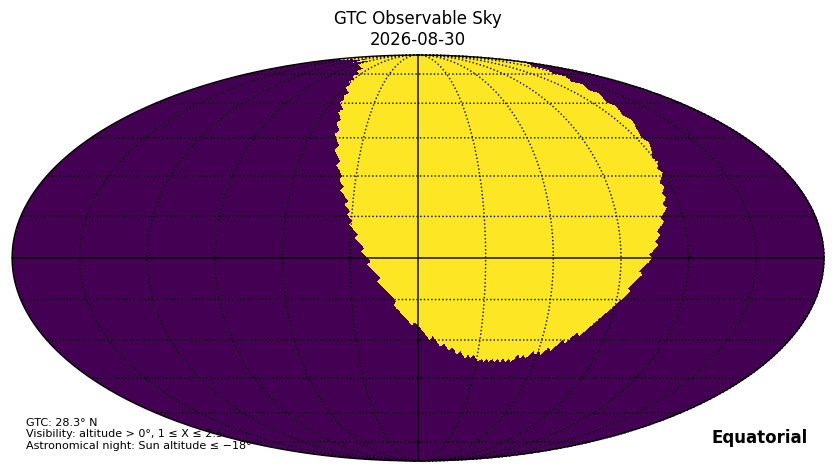

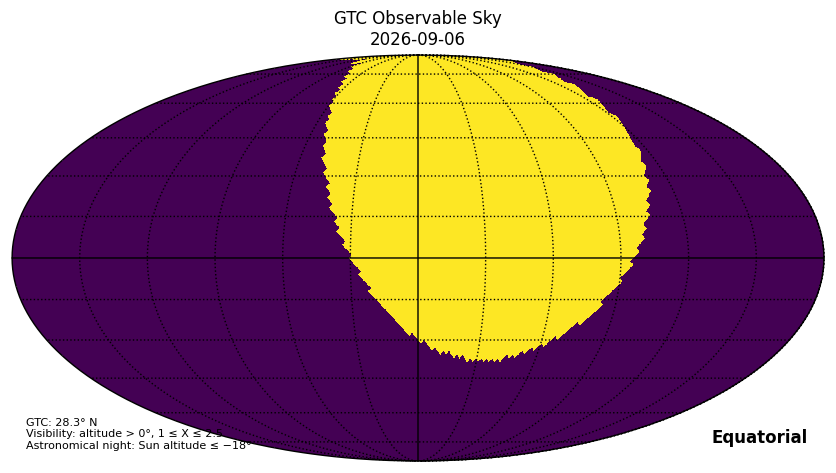

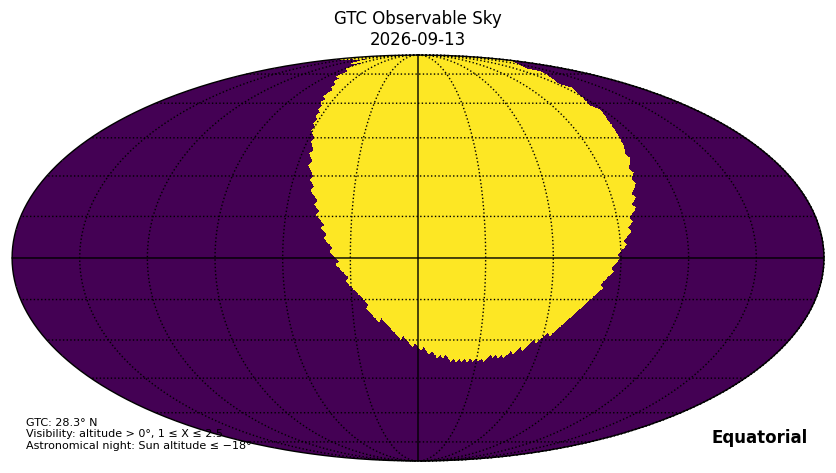

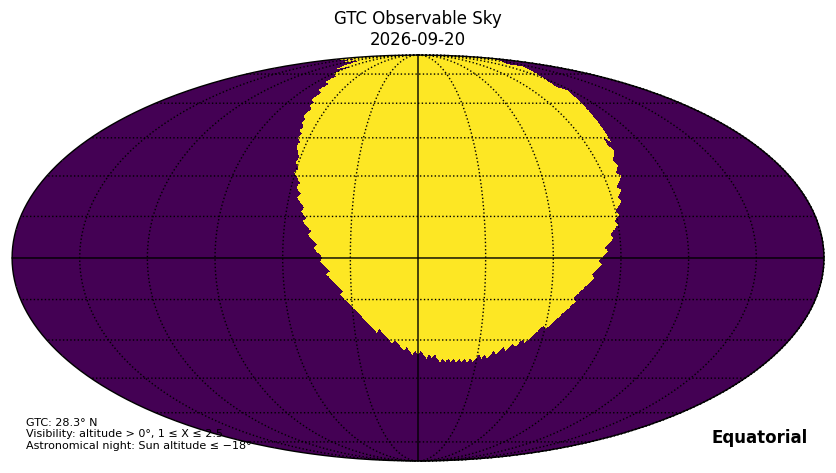

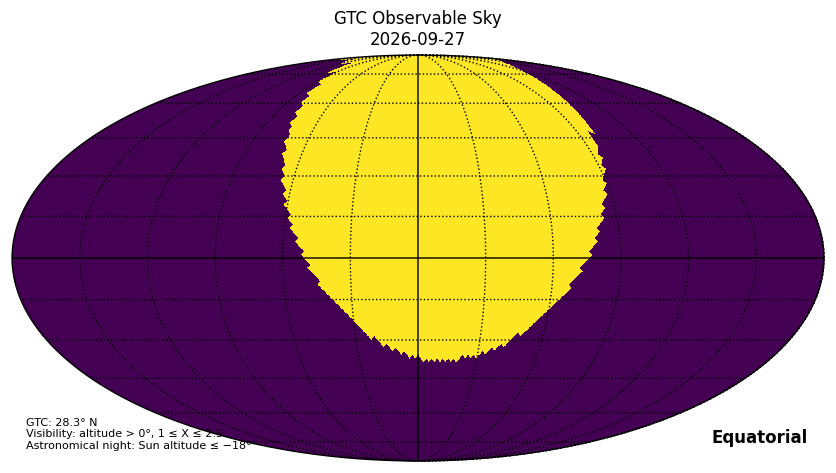

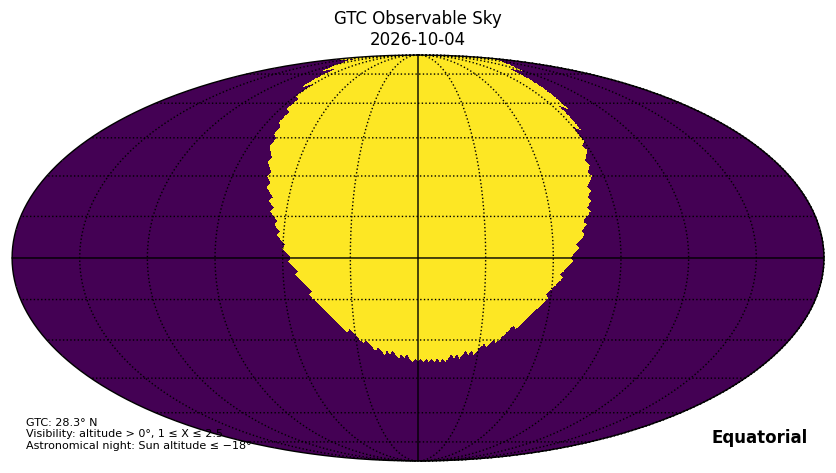

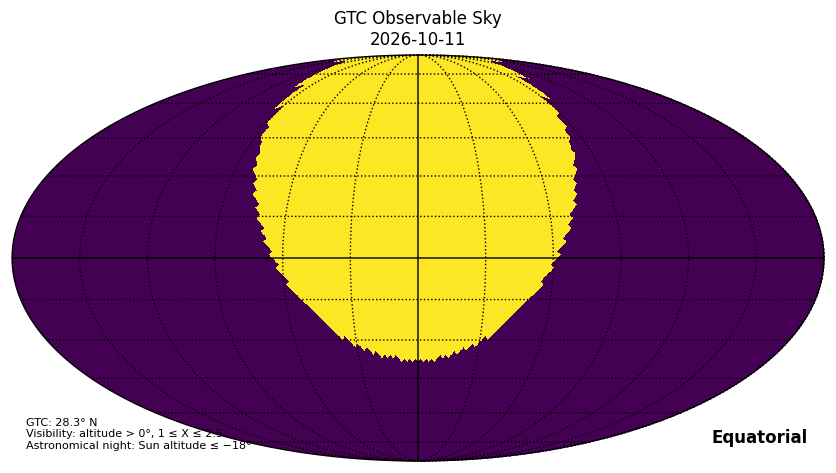

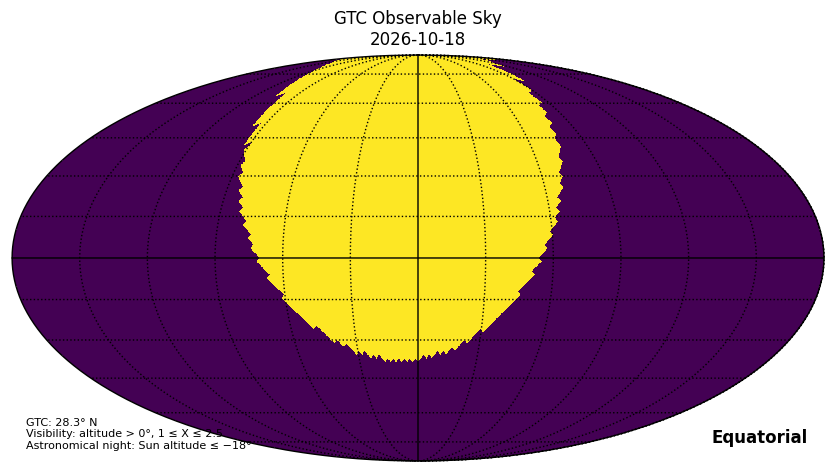

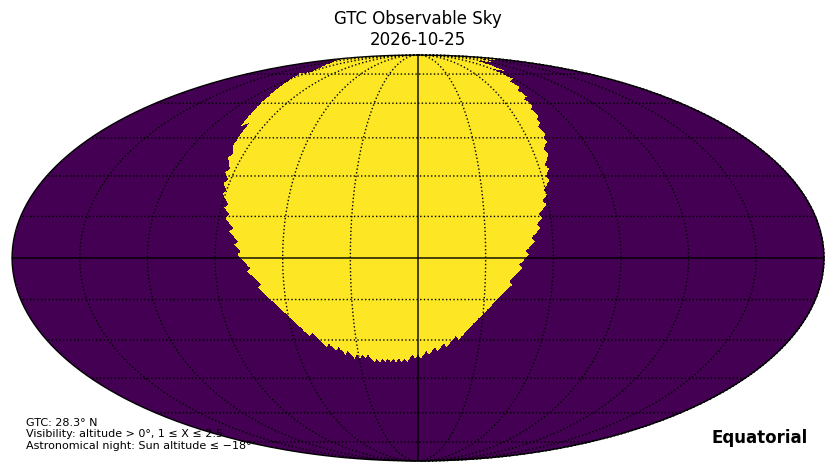

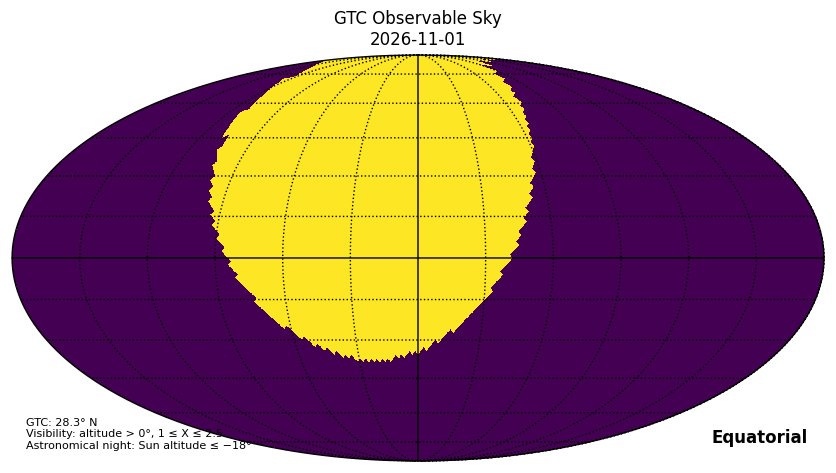

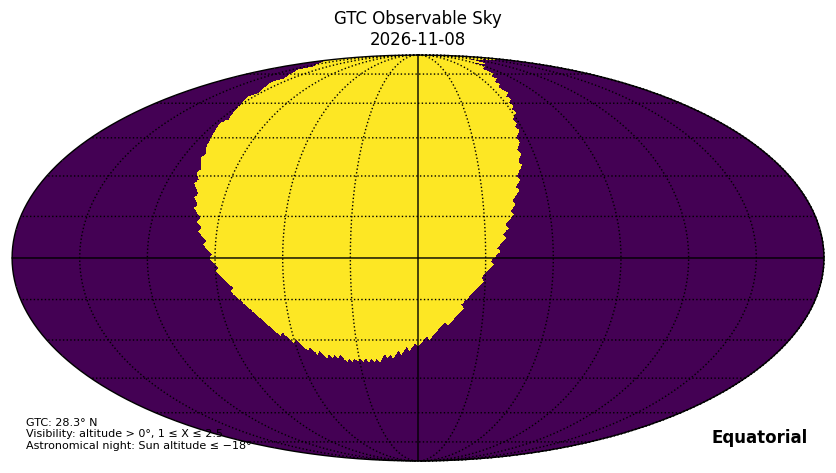

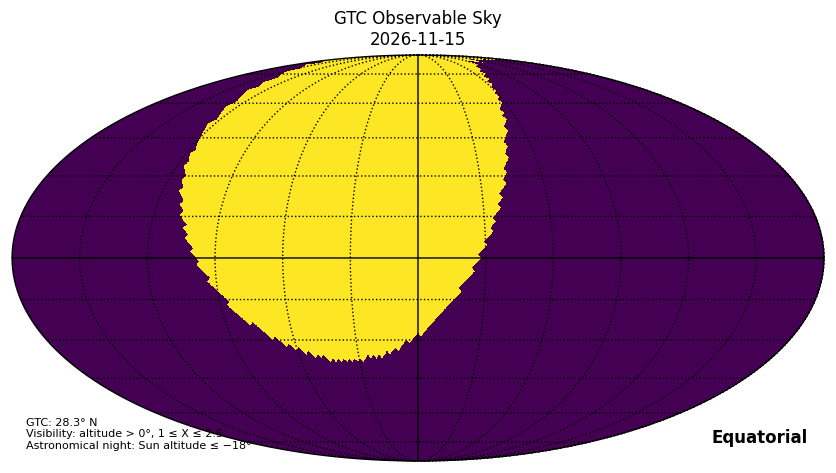

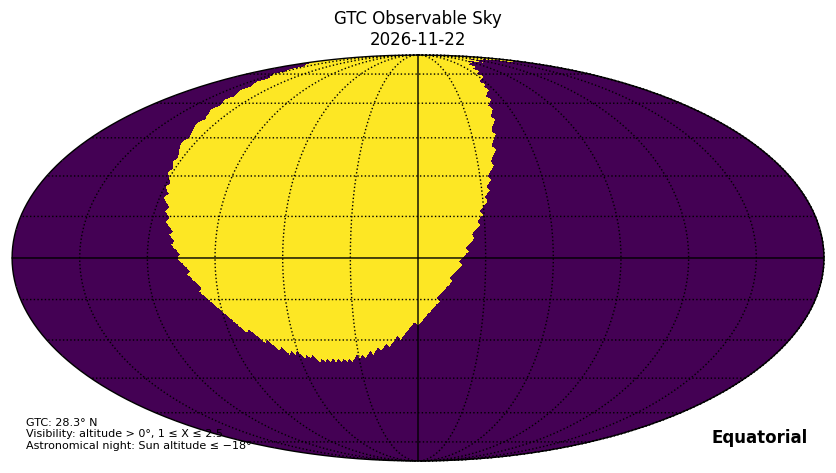

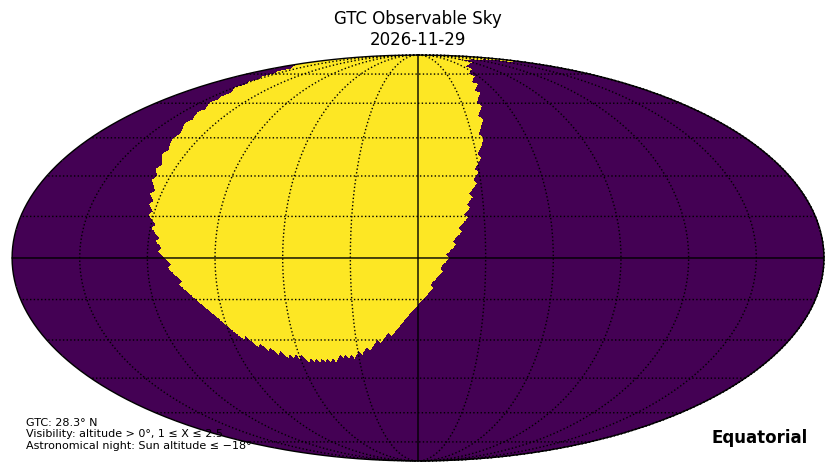

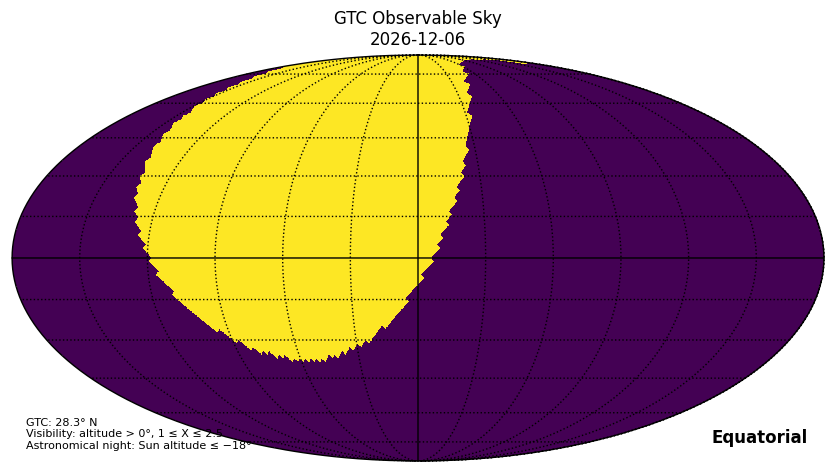

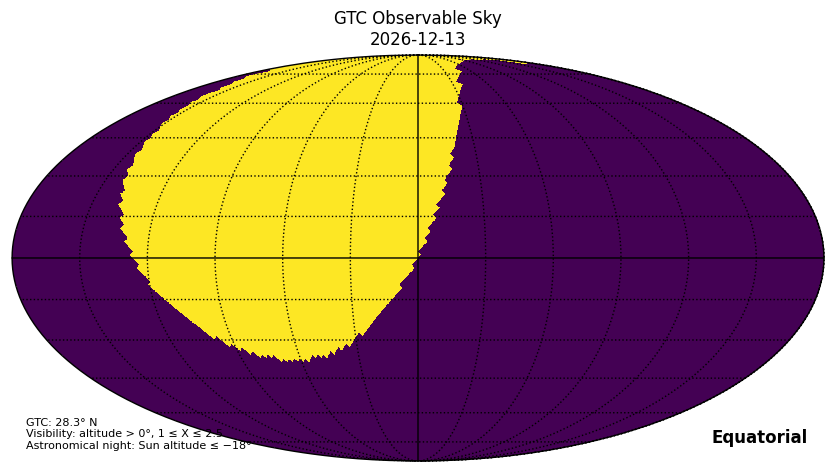

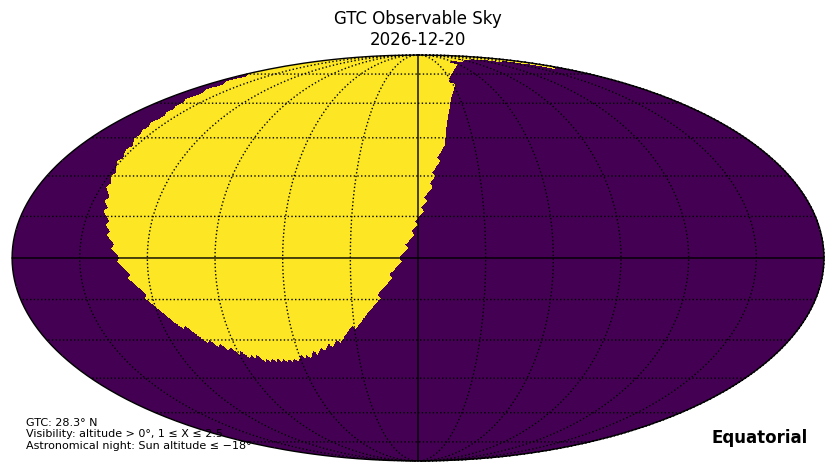

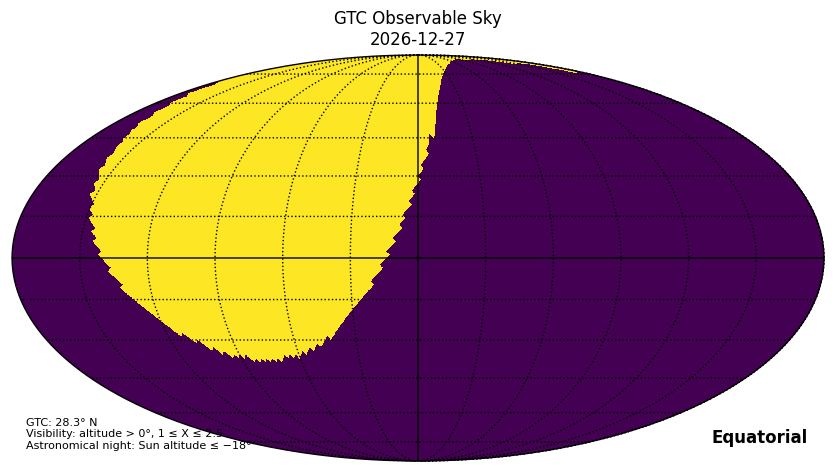

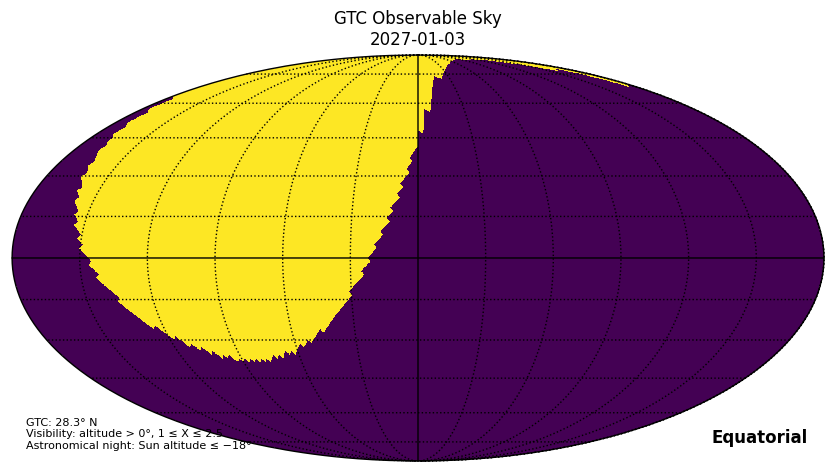

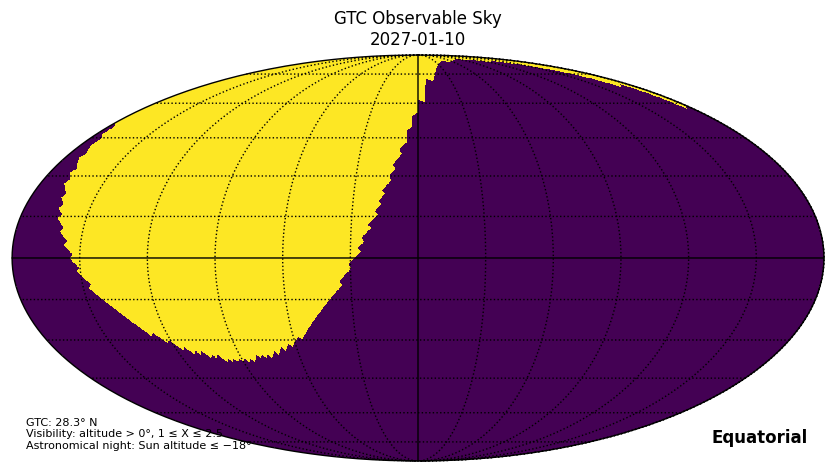

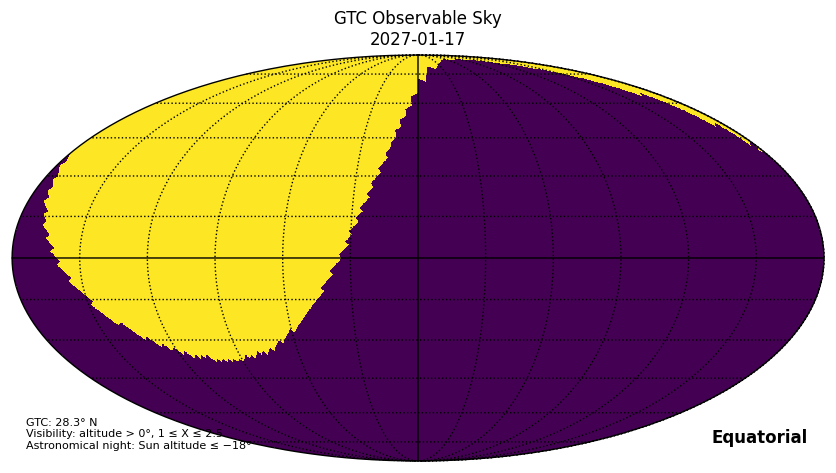

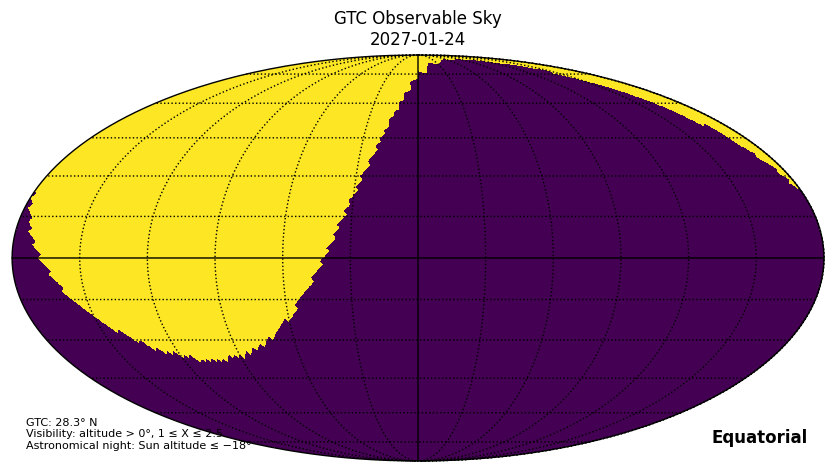

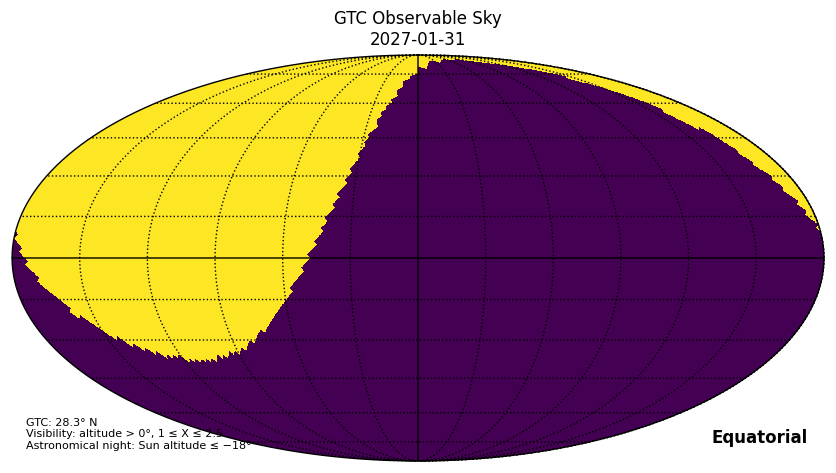

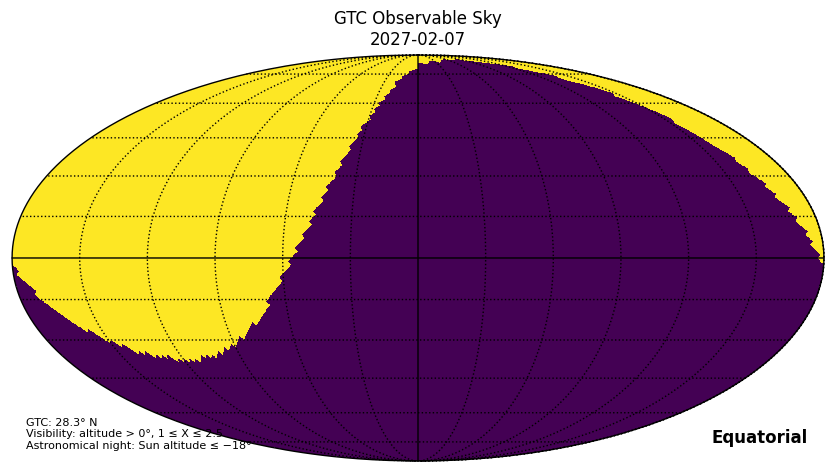

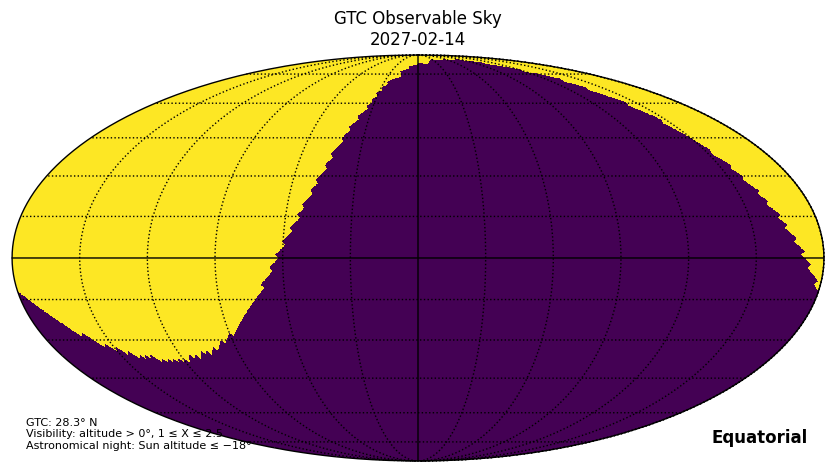

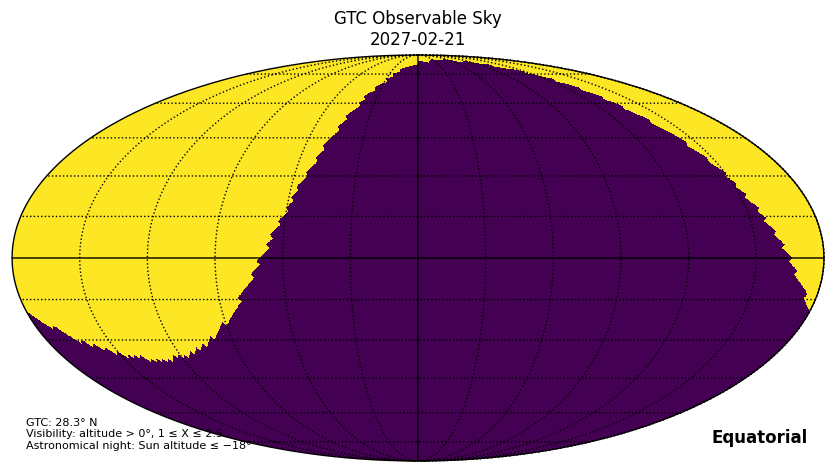

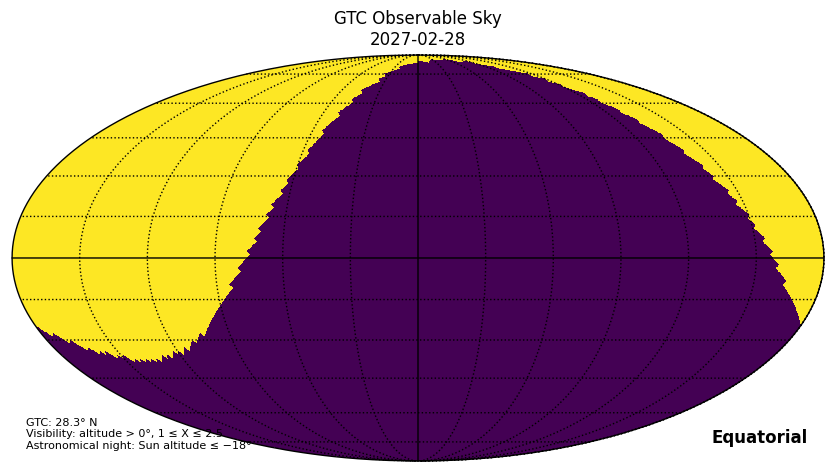

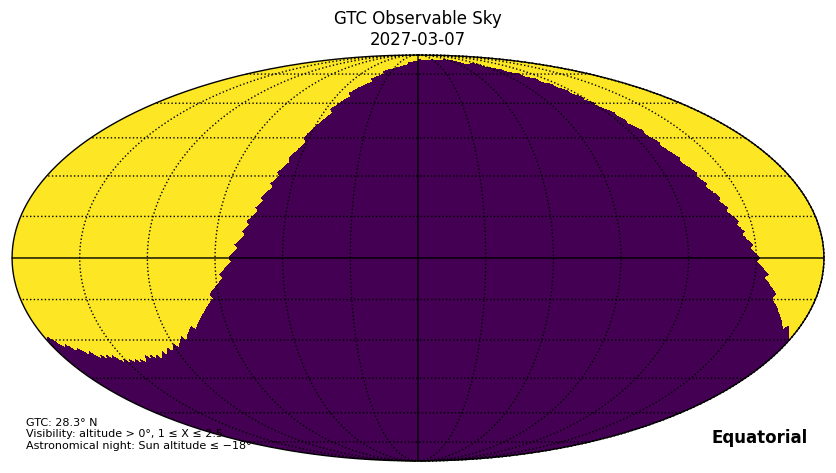

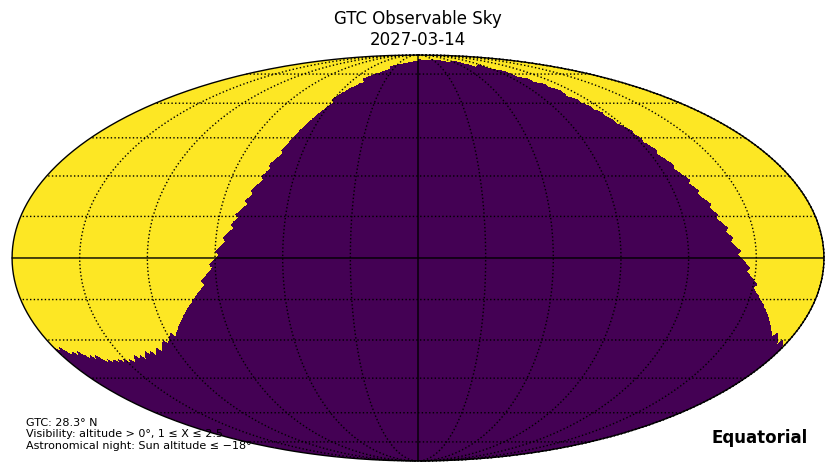

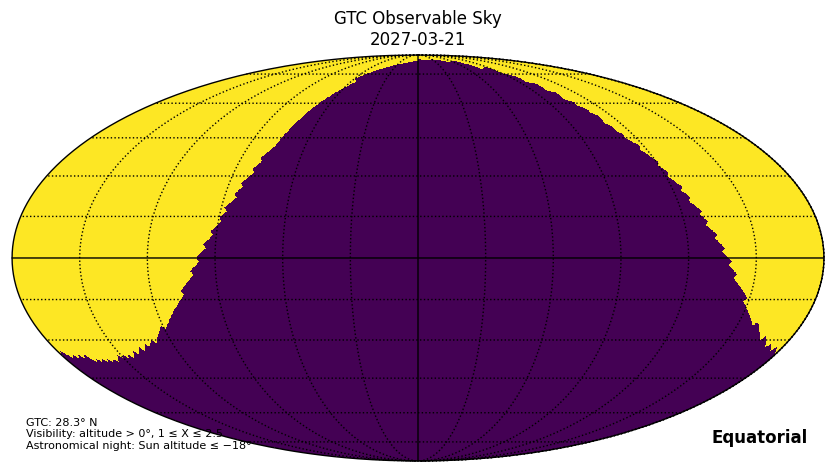

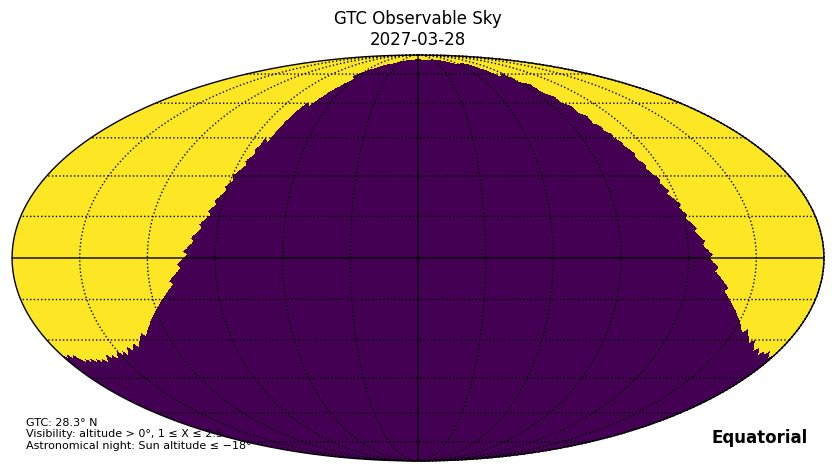

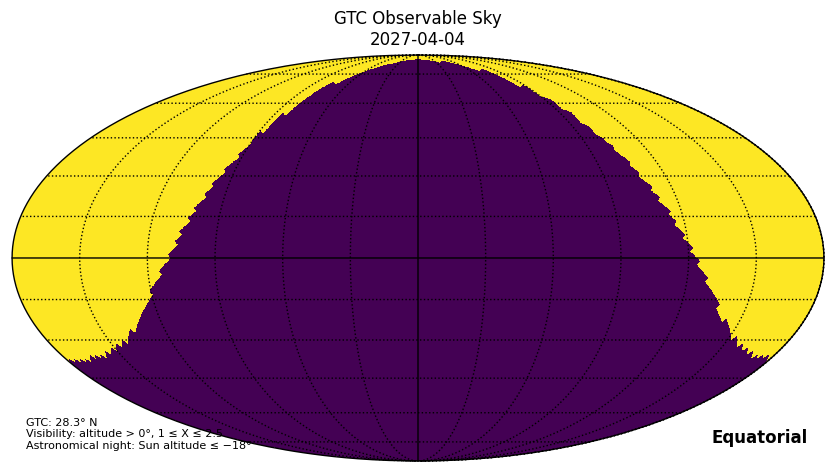

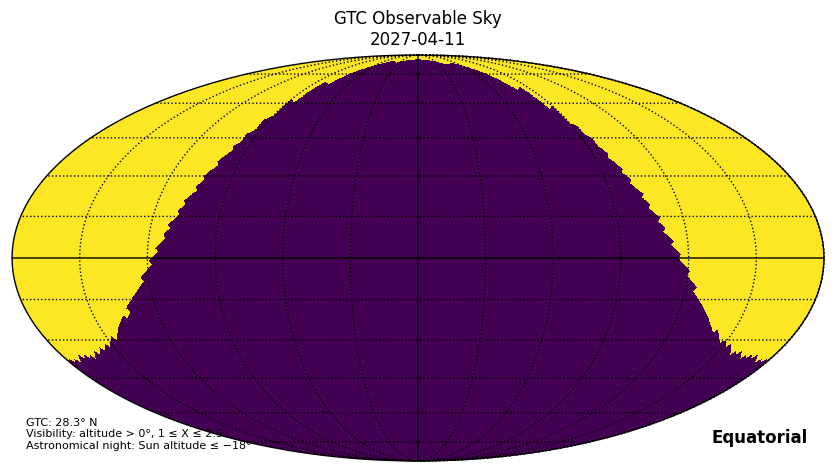

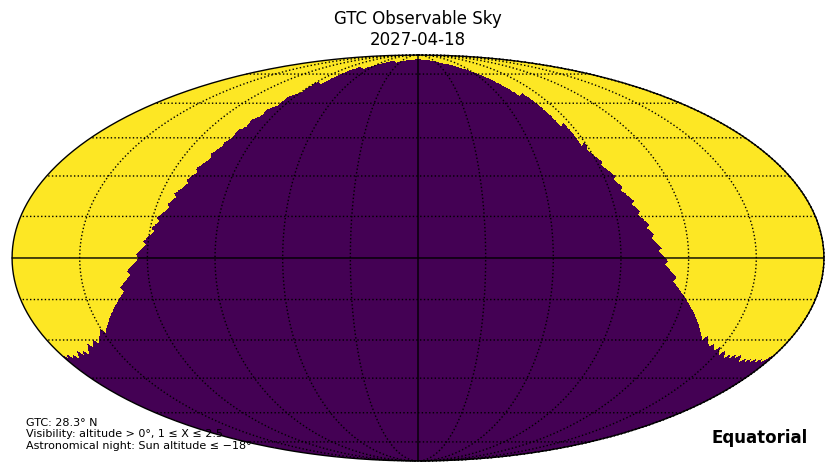

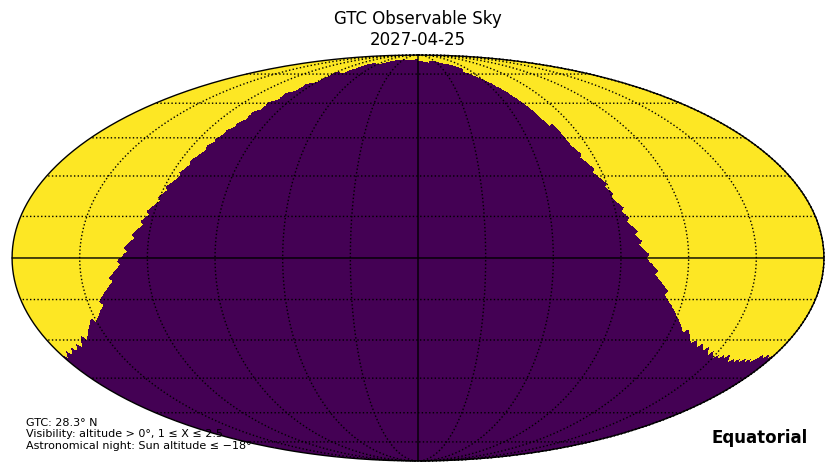

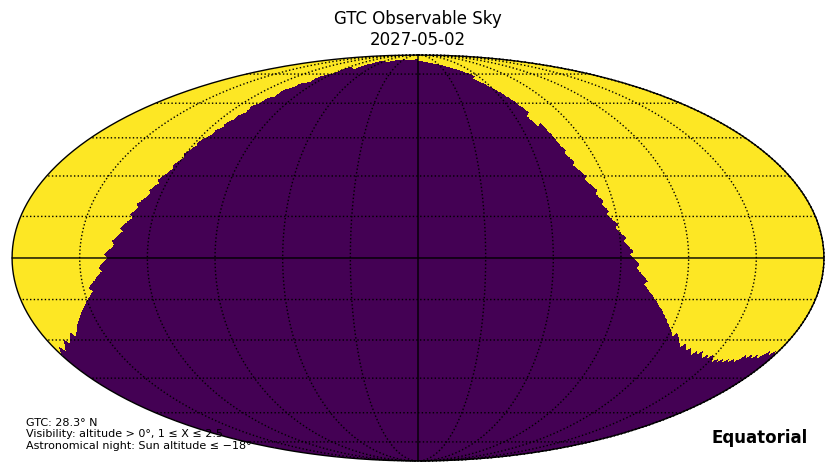

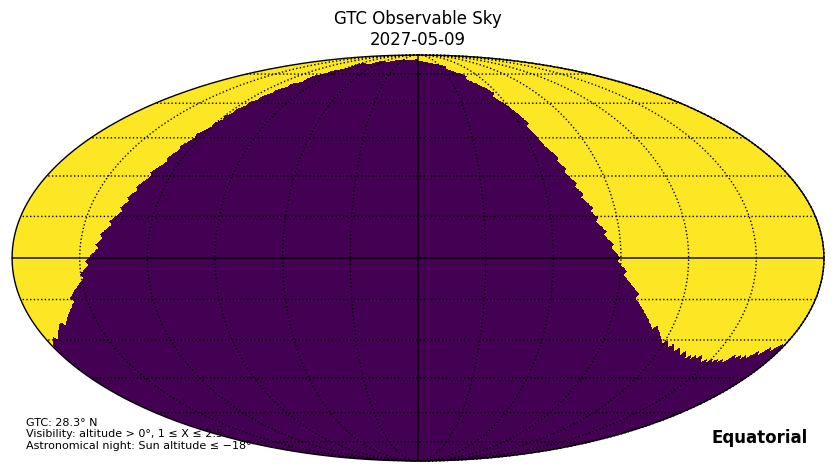

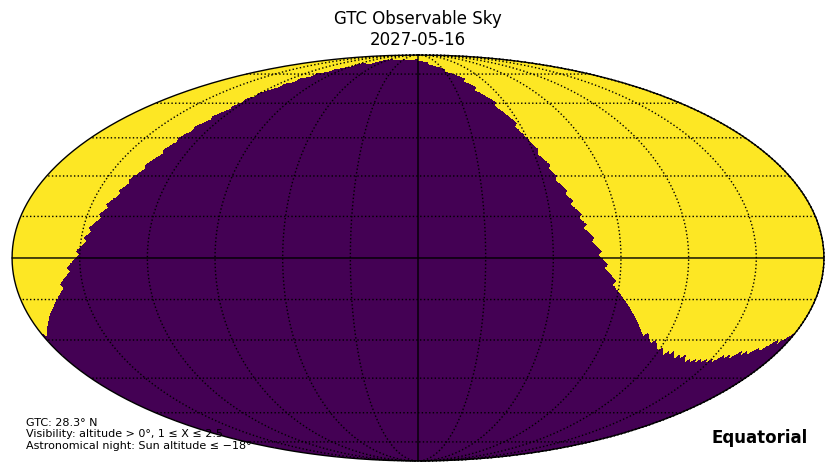

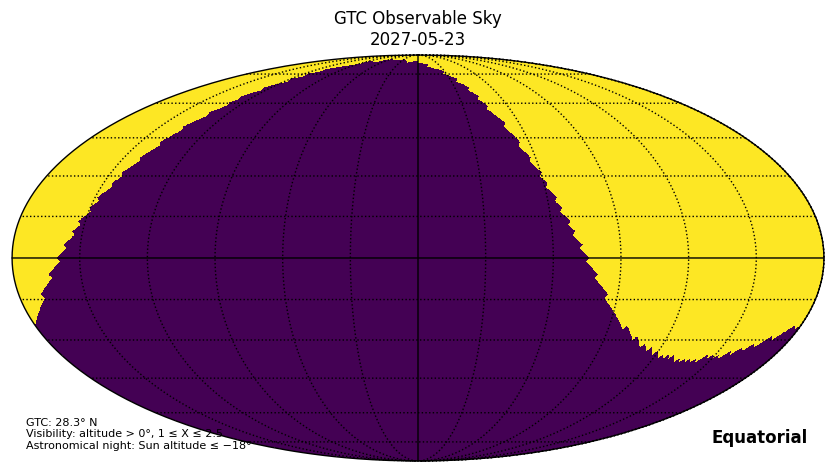

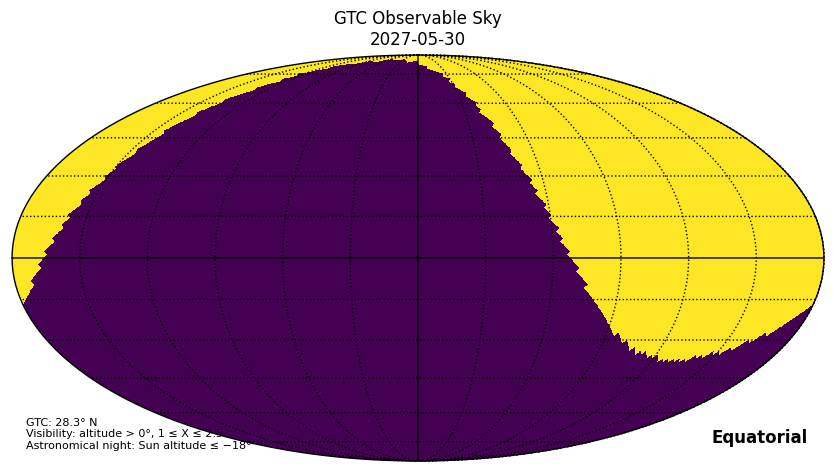

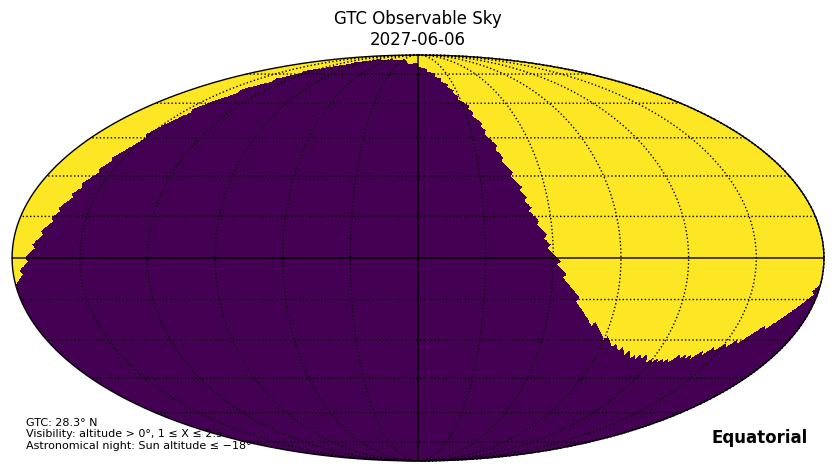

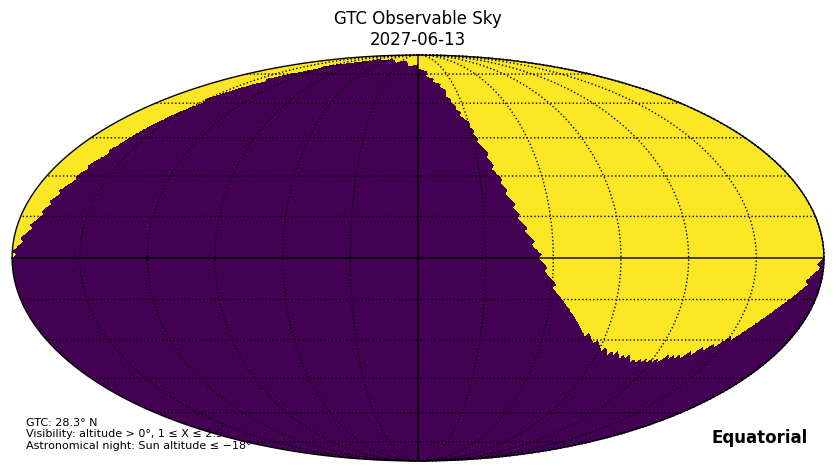

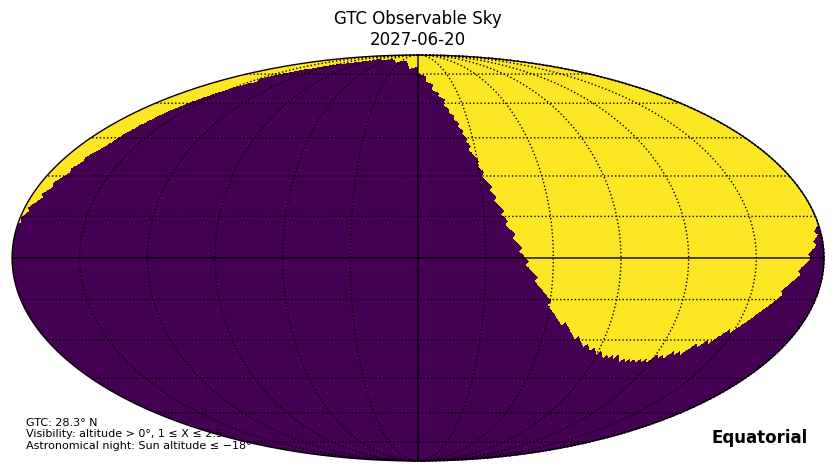

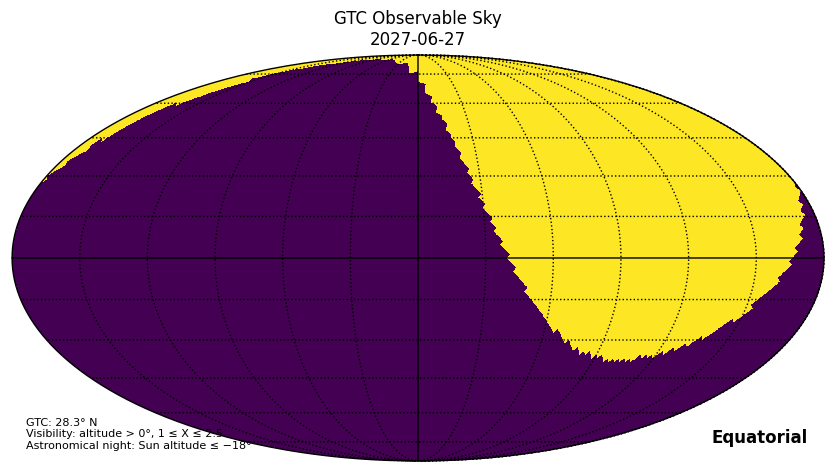

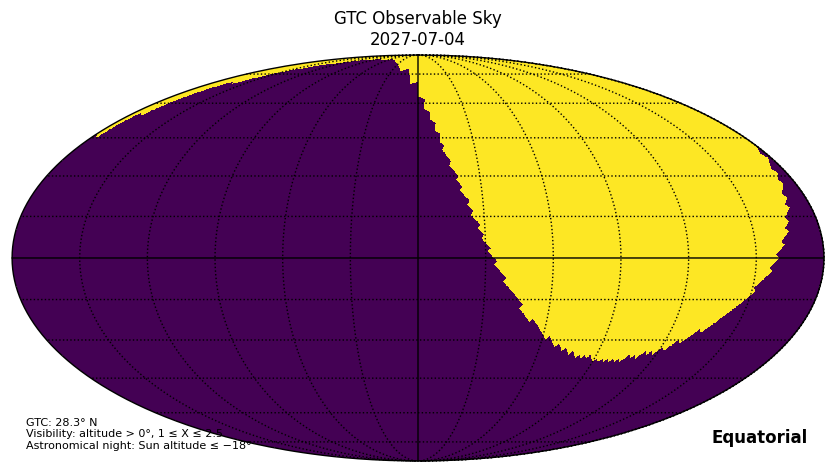

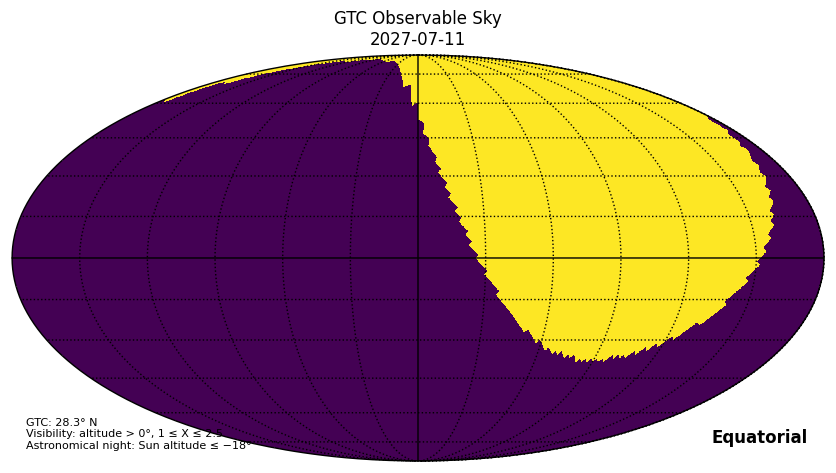

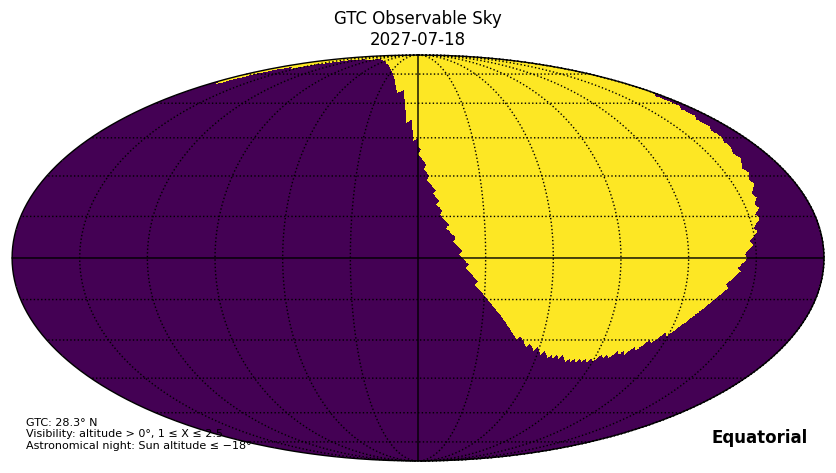

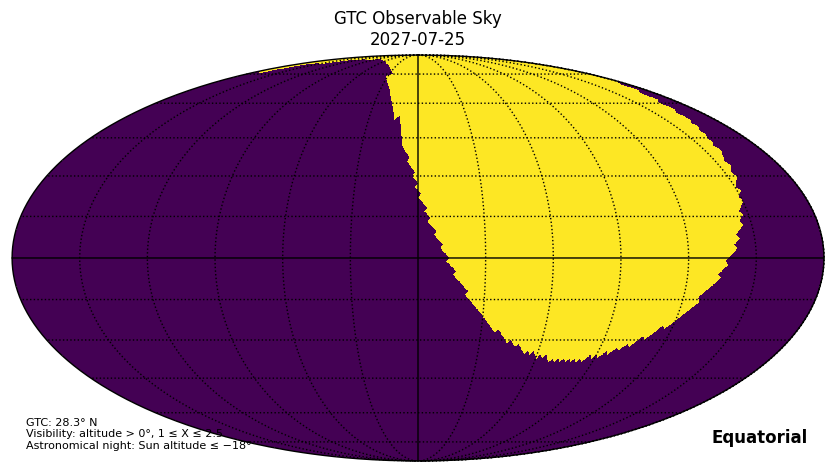

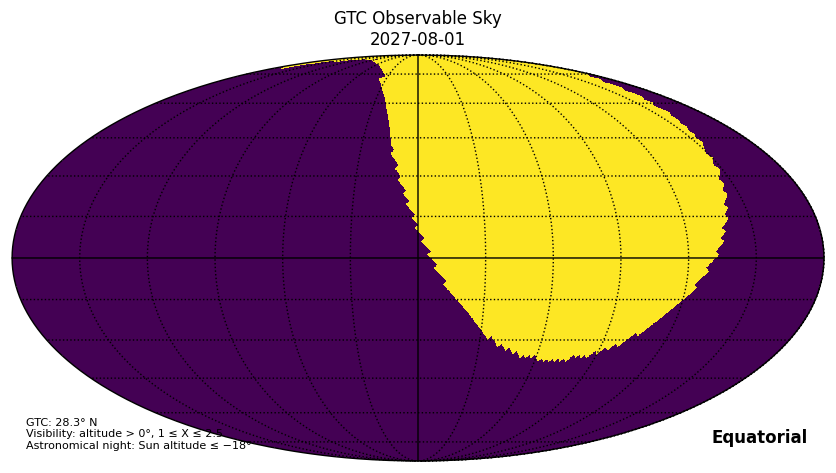

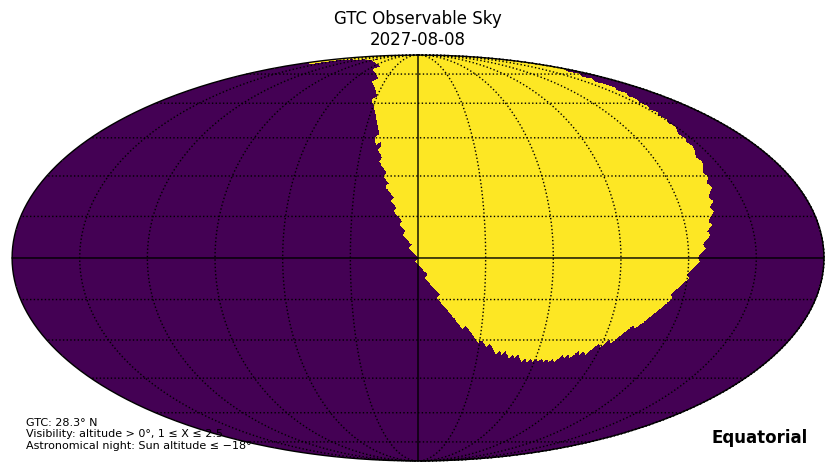

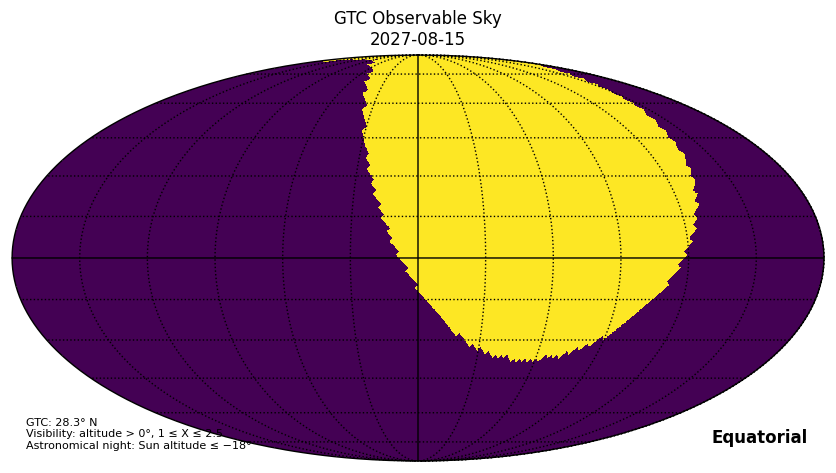

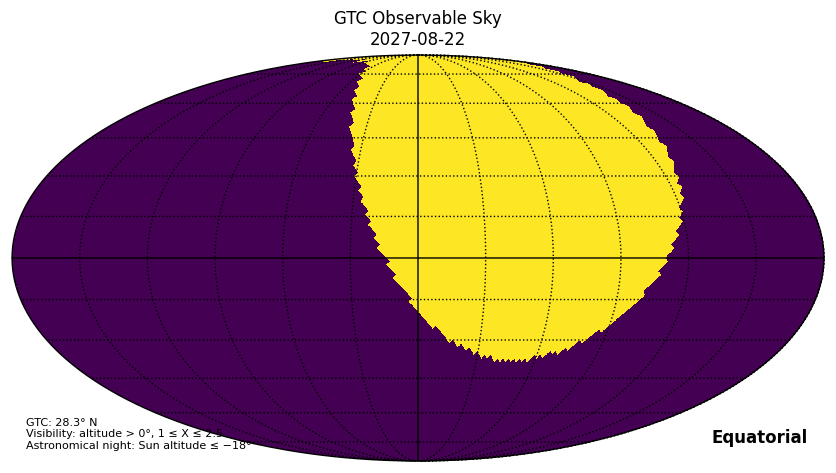

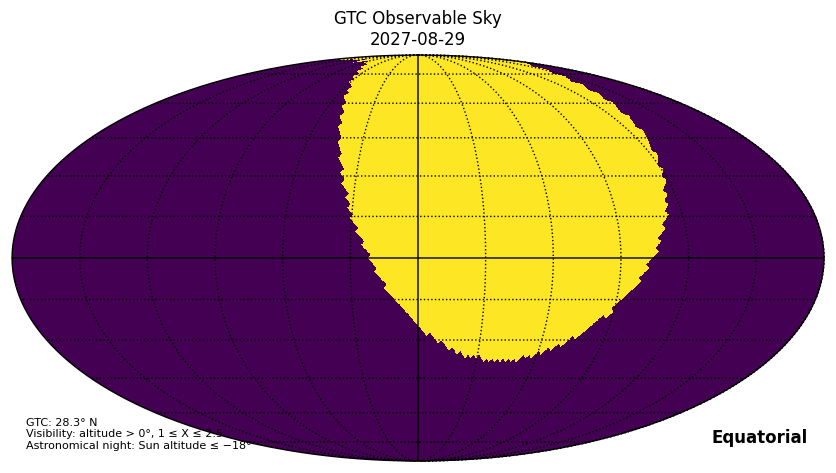

All weekly frames generated.
GIF created successfully.
Frames: 53
GIF: assignment_outputs/gtc_visibility_year.gif


In [ ]:
# Q20 ANSWER:

import os
import glob
import healpy as hp
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt

# Output directories
output_dir = "assignment_outputs"
frame_dir = os.path.join(output_dir, "q20_frames")

os.makedirs(frame_dir, exist_ok=True)

# Remove old frames so they do not mix with the new GIF
for old_file in glob.glob(os.path.join(frame_dir, "*.png")):
    os.remove(old_file)


# Weekly dates 2026-08-30 to 2027-08-29
q20_start = Time(
    "2026-08-30T00:00:00",
    scale="utc"
)

q20_end = Time(
    "2027-08-29T00:00:00",
    scale="utc"
)

q20_dates = q20_start + np.arange(
    int((q20_end - q20_start).to_value(u.day) / 7) + 1
) * 7 * u.day

print("Number of weekly frames:", len(q20_dates))


# HEALPix sky grid
nside = 32

npix = hp.nside2npix(nside)

pix = np.arange(npix)

theta, phi_hp = hp.pix2ang(
    nside,
    pix
)

# HEALPix -> ICRS
ra_hp = phi_hp * u.rad

dec_hp = (
    np.pi / 2 - theta
) * u.rad

sky = SkyCoord(
    ra=ra_hp,
    dec=dec_hp,
    frame="icrs"
)

# Generate weekly frames

for frame_number, date in enumerate(q20_dates):

    # GTC AltAz frame
    frame_altaz = AltAz(
        obstime=date,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    # Transform entire HEALPix sky to GTC AltAz
    sky_altaz = sky.transform_to(frame_altaz)

    # Sun altitude
    sun_altitude_q20 = get_sun(date).transform_to(
        frame_altaz
    ).alt

    # Airmass
    X = np.asarray(
        sky_altaz.secz.value,
        dtype=float
    )

    # GTC visibility criteria
    # Above horizon
    # 1 <= X <= 2.5
    # Astronomical night: Sun <= -18 deg

    visible = (
        (sky_altaz.alt > 0 * u.deg)
        &
        np.isfinite(X)
        &
        (X >= 1)
        &
        (X <= 2.5)
        &
        (sun_altitude_q20 <= -18 * u.deg)
    )

    # HEALPix map
    hp_map = np.zeros(npix)

    hp_map[visible] = 1


    # Create Mollweide map
    hp.mollview(
        hp_map,
        fig=1,
        coord="C",
        rot=(0, 0, 0),
        title=(
            f"GTC Observable Sky\n"
            f"{date.utc.isot[:10]}"
        ),
        unit="Visible",
        min=0,
        max=1,
        cbar=False,
        notext=False,
        xsize=1800
    )

    # Add coordinate grid
    hp.graticule(
        dmer=30,
        dpar=15,
        verbose=False
    )

    # Add custom text
    plt.text(
        0.02,
        0.03,
        "GTC: 28.3° N\n"
        "Visibility: altitude > 0°, 1 ≤ X ≤ 2.5\n"
        "Astronomical night: Sun altitude ≤ −18°",
        transform=plt.gca().transAxes,
        fontsize=8,
        verticalalignment="bottom"
    )

    # Save frame

    frame_path = os.path.join(
        frame_dir,
        f"frame_{frame_number:03d}.png"
    )

    plt.savefig(
        frame_path,
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
    plt.close("all")


print("All weekly frames generated.")


# Create GIF

frame_files = sorted(
    glob.glob(
        os.path.join(
            frame_dir,
            "frame_*.png"
        )
    )
)

frames = [
    imageio.imread(filename)
    for filename in frame_files
]

gif_path = os.path.join(
    output_dir,
    "gtc_visibility_year.gif"
)

imageio.mimsave(
    gif_path,
    frames,
    duration=0.7,
    loop=0
)

print("GIF created successfully.")
print("Frames:", len(frames))
print("GIF:", gif_path)

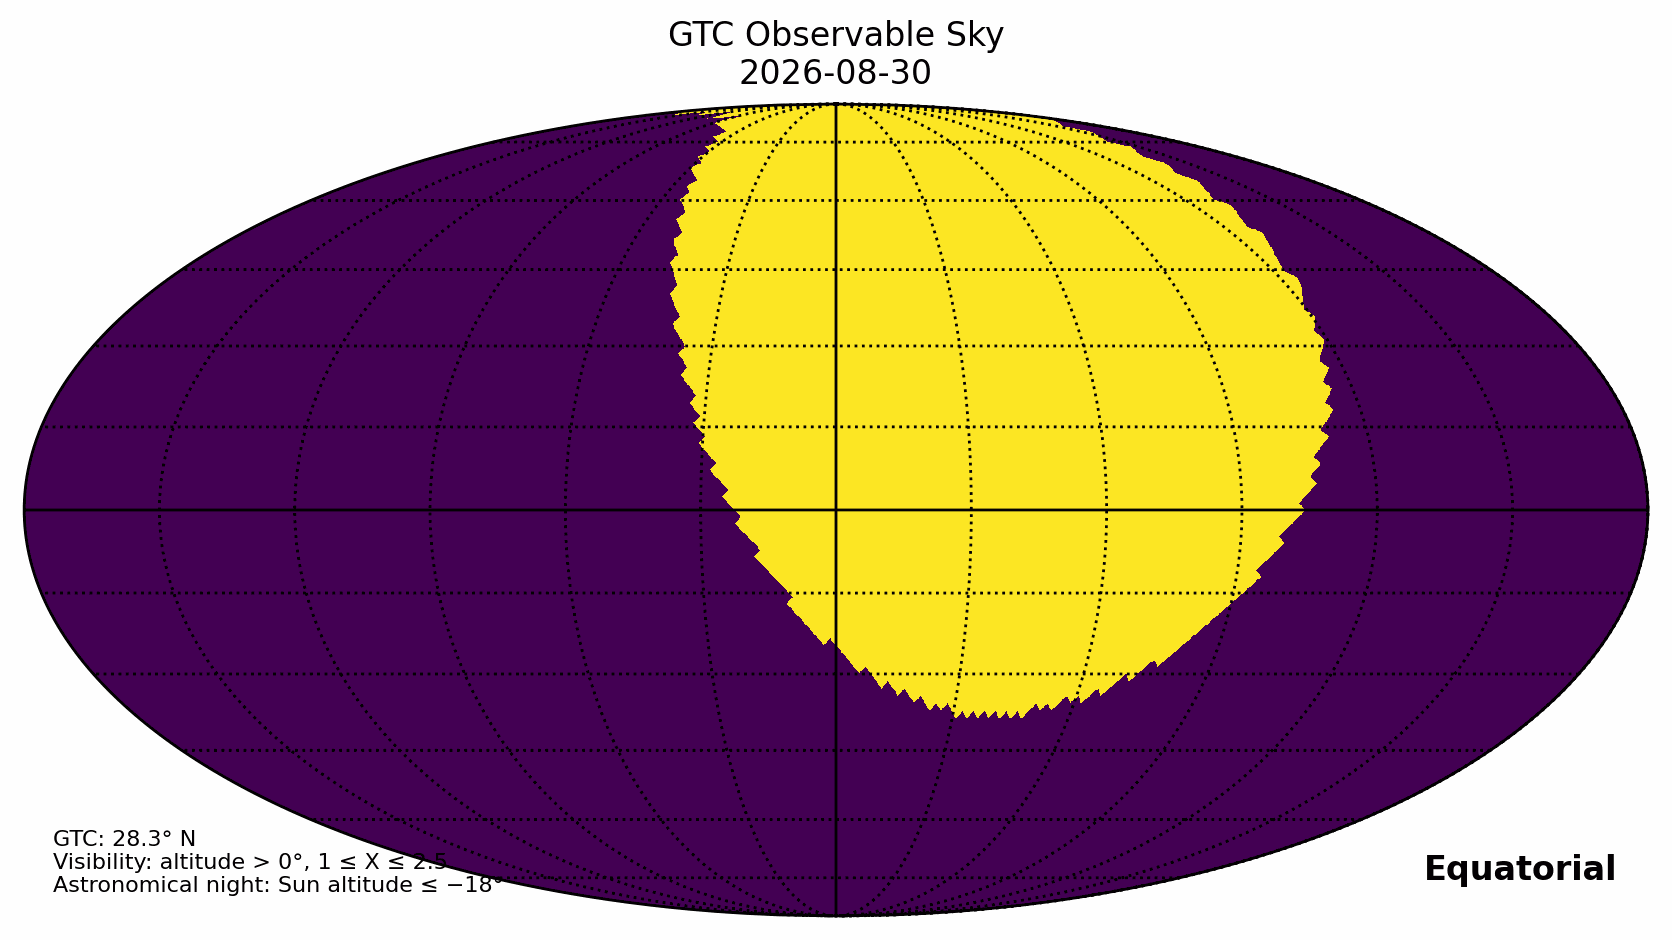

In [ ]:
from IPython.display import Image, display

display(Image(
    filename="assignment_outputs/gtc_visibility_year.gif"
))

Q20 Explanation: The visibility changes throughout the year because Earth's orbital motion changes the Sun's apparent position relative to the fixed celestial coordinate grid.  
The GTC altitude and airmass constraints also depend on the position of each source relative to the observatory's latitude and local meridian.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
